[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shanahdt/huji_summer_class_2026/blob/main/notebooks/day5_information.ipynb)

# Day 5: Information, Surprise, and What Music Tells Us
**Date:** Thursday 25 June 2026

- What does it mean to say a melody is "complex"?
- How does the answer change depending on what the listener already knows?
- Can we measure surprise? And if so, whose surprise?


In [1]:
# Setup: clone repo if in Colab, add utils to path, import libraries
import os, sys, subprocess
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, linregress, pearsonr

repo_url = 'https://github.com/shanahdt/huji_summer_class_2026.git'
repo_name = 'huji_summer_class_2026'

if not os.path.exists('../data'):
    if not os.path.exists(f'/content/{repo_name}'):
        subprocess.run(['git', 'clone', repo_url], check=True)
    os.chdir(f'/content/{repo_name}/notebooks')
    print('Cloned and ready.')
else:
    print('Running locally -- data directory found.')

repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 4)
print('Setup complete.')


Running locally -- data directory found.
Setup complete.


## Part 1: The Prehistory of Entropy

Jon Barwise (1986) described the challenge of information theory with a
railway metaphor: one track heads east trying to understand how agents
process information; another heads west trying to understand what
information is. "One hopes that these tracks will meet."

Today we're going to focus on the the early attempts to quantify
"complexity" in music (which is often conflated with aesthetic ideas of "beauty"), 
through Claude Shannon's mathematical theory, to modern computational
models of musical expectation. 

At each stage, the same question keeps coming back: whose idea of a listener are we modeling?


### Hartley (1928): information without probability

Ralph Hartley's 1928 formula:

**H = n log₂ s**

where n = number of symbols, s = number of possible values.

Applied to the two fight songs in the Acevedo/Shanahan chapter:

- UConn fight song: 85 notes, 12 possible pitch classes
- Northwestern fight song: 142 notes, 12 possible pitch classes

The obvious problem: Northwestern scores higher *only because it has more
notes*. A melody that repeats the same note 142 times gets the same
Hartley score as one that uses all 12 pitch classes with perfect
equality. Hartley has no concept of probability.


In [2]:
from utils import hartley_information
# Hartley (1928): H = n x log2(s)
# Counts bits needed to identify one melody out of all possible
# melodies of that length, assuming all pitches equally likely
hartley_information(142, 12)  # Northwestern fight song
hartley_information(85, 12)   # UConn fight song
hartley_information(142, 12)  # 142-note monotone -- same answer!


142 notes with 12 possible values = 509.06 bits (Hartley 1928)
85 notes with 12 possible values = 304.72 bits (Hartley 1928)
142 notes with 12 possible values = 509.06 bits (Hartley 1928)


509.0646751024042

### What just happened -- and what's wrong with it

Hartley's formula **H = n x log2(s)** counts how many bits you need to
identify one specific melody out of all possible melodies of that
length, assuming every pitch is equally likely.

The Northwestern fight song (142 notes) and a 142-note drone on a
single pitch get **identical scores** -- because Hartley has no
mechanism for the fact that some pitches are common and others are
rare. He treats every sequence of 142 notes as equally probable.

This is the fundamental limitation: Hartley measures the size of the
*message space*, not the actual distribution of symbols within the
message. Shannon fixes this by weighting each symbol by its actual
probability -- so a common pitch contributes less information than a
rare one.


### Birkhoff (1933): beauty as order over complexity

George Birkhoff proposed: **M = O/C** -- beauty equals order divided by
complexity.

The assumptions baked in:

- Beauty can be measured
- It is tied to pattern recognition
- It is universal across musical cultures

For musical "order," Birkhoff used Ebenezer Prout's counterpoint rules
from 1890 -- rating sequences as "good," "possible," or "bad."

It's worth considering what this would mean for a corpus that doesn't align with 
these rules. For example, a fight song? A Carnatic raga? Birkhoff's answer was whatever Western
counterpoint rules said. His listener was actually a very
specific listener.


### Shannon (1948): adding probability

Claude Shannon's key move: instead of counting symbols, weight by how
likely each symbol is.

**H(X) = −Σ p(x) log₂ p(x)**

Rare events carry more information than common ones. If Q is followed
by U 99% of the time, that U conveys almost no information. If 7̂
resolves to 1̂ 80% of the time in tonal music, that resolution is
low-information -- expected.

Shannon demonstrated this by having his wife predict letters in a
Raymond Chandler novel one at a time. She got better as she went along,
and made most errors at the beginning of words -- when context was
thin. The musical parallel: we expect more at phrase endings than at
phrase beginnings.

Pinkerton (1956) applied this directly to melody, writing that "the
composer of a melody must make the entropy of his music low enough to
give it an apparent pattern and at the same time high enough so that it
has sufficient complexity to be interesting."


## Part 2: Entropy in Code

Shannon entropy can be applied to music at three levels:

1. **Unigram entropy**: how spread out is the pitch distribution? (how
   often does each note appear?)
2. **Conditional entropy**: how predictable are note-to-note
   transitions? (how much does knowing the previous note help?)
3. **Cross-entropy**: how surprising is this piece to a listener
   trained on a different style? (IDyOM -- we get to this in Part 6.)

Crucially: the answer to each question depends entirely on what you
choose to measure. The same piece has different entropy values
depending on whether you measure pitch names, scale degrees,
intervals, or contour.


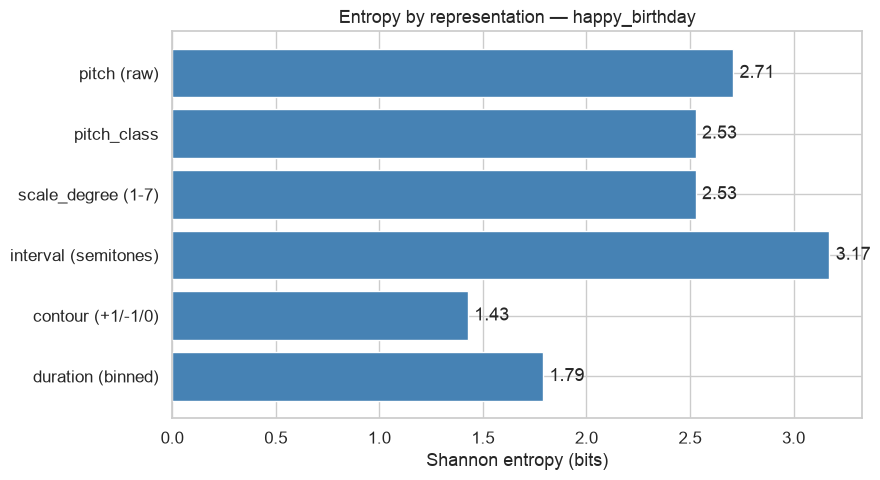

,representation,entropy,n_unique_symbols,n_events
0,pitch (raw),2.709275,8,25
1,pitch_class,2.528102,7,25
2,scale_degree (1-7),2.528102,7,25
3,interval (semitones),3.173533,11,24
4,contour (+1/-1/0),1.428412,3,24
5,duration (binned),1.791737,5,25


In [3]:
# Compute Shannon entropy for Happy Birthday across 6 representations
# This shows that entropy is a property of the representation, not the piece
from utils import compare_entropy_representations

compare_entropy_representations('../data/happy_birthday.krn', plot=True)


### What does this mean?

The same piece -- the same sequence of notes -- has different entropy
values depending on what you choose to measure:

- **Pitch names** (G4, A4, B4...): each pitch is unique, many symbols,
  moderate entropy
- **Pitch classes** (0-11): collapses octaves, fewer symbols
- **Scale degrees** (1-7): normalizes to key, captures tonal function
- **Intervals** (semitones): captures motion between notes,
  key-independent
- **Contour** (+1/0/-1): collapses all interval information to just
  direction
- **Durations**: captures rhythmic variety (Note lengths are grouped into standard categories (eighth, quarter, dotted quarter, half, etc.) and entropy is computed over those categories rather than exact float values. The moderate entropy reflects that Happy Birthday has a characteristic dotted
quarter–eighth rhythmic pattern that repeats heavily — rhythm here is *more* predictable than pitch, which makes musical sense:
you probably knew the rhythm before you could name the notes.)


Much like we've been discusing for most of this class, 
every entropy value is an entropy value FOR A SPECIFIC 
REPRESENTATION. The representation choice is aclaim about 
what matters about music.


43 piece(s) — entropy (scale_degree): mean=2.456, median=2.491, min=1.797, max=2.766


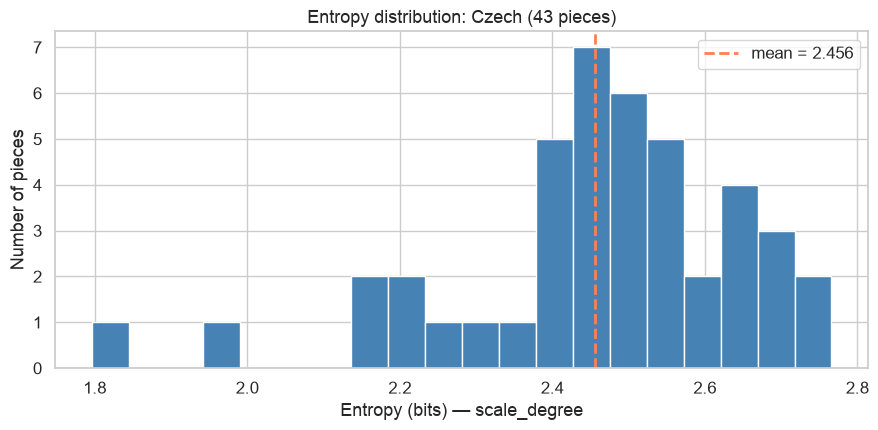

,tune_id,entropy,n_notes
0,czech01,2.626678,30
1,czech02,2.501930,26
2,czech03,2.393582,18
3,czech04,2.545090,26
4,czech05,2.188722,12
5,czech06,2.398873,31
6,czech07,2.341496,31
7,czech08,2.622901,26
8,czech09,2.491205,27
9,czech10,2.664545,29


In [4]:
# Compute Shannon entropy for every piece in the Czech Essen corpus
# Returns a DataFrame so we can do statistics on the distribution
from utils import corpus_entropy_profile

czech_entropy = corpus_entropy_profile(
    '../data/Essen/Czech',
    representation='scale_degree',
    verbose=False,
    plot=True)
czech_entropy.head(10)


H(note | previous 1) — Czech folk: 2.368 bits
H(note | previous 1) — Charlie Parker: 2.765 bits
Difference (Czech folk - Charlie Parker): -0.397 bits


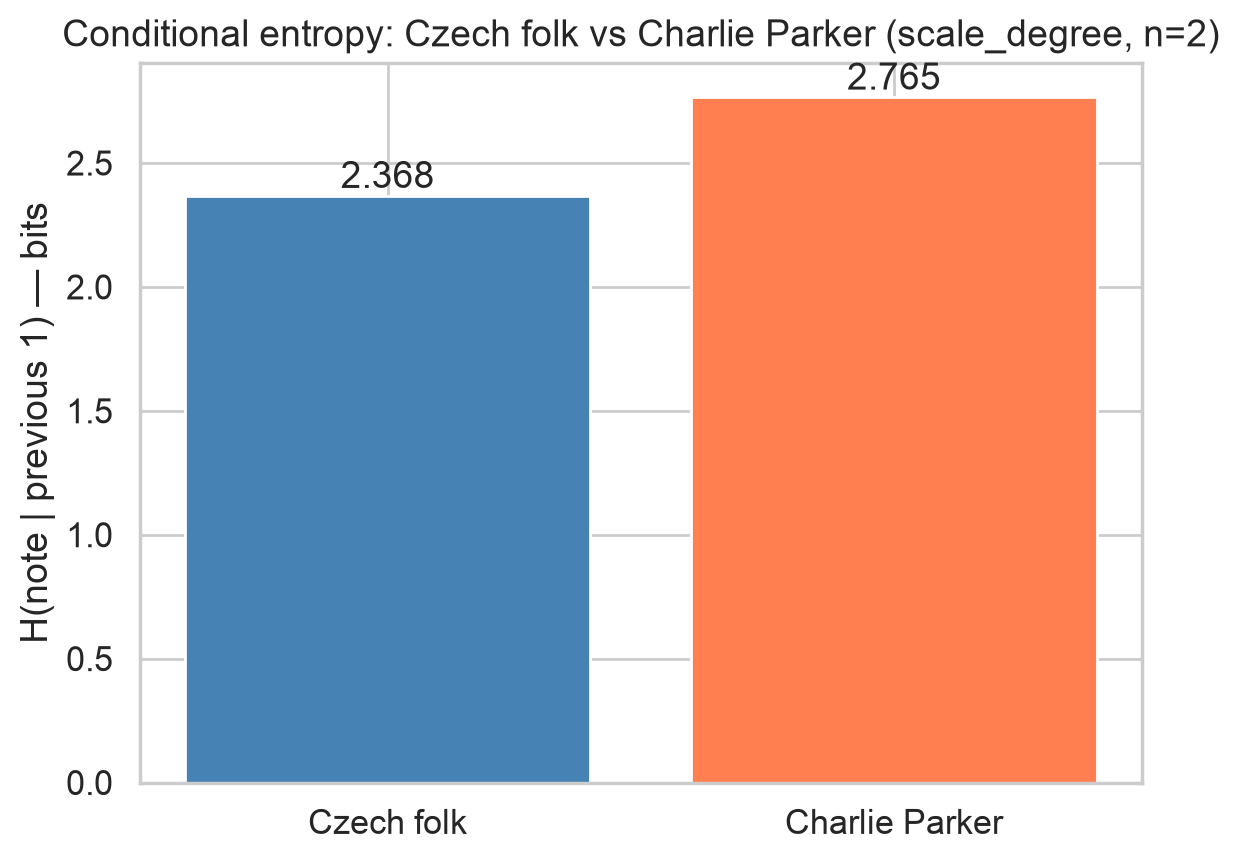

{'entropy_a': 2.3684158395985833,
 'entropy_b': 2.765347720966176,
 'difference': -0.3969318813675926,
 'n': 2,
 'names': ('Czech folk', 'Charlie Parker')}

In [5]:
# Compare how predictable note-to-note transitions are in two corpora
# Conditional entropy H(X_n | X_(n-1)) answers:
# once you know the previous note, how uncertain is the next one?
from utils import compare_corpus_conditional_entropy

compare_corpus_conditional_entropy(
    '../data/Essen/Czech',
    '../data/charlie_parker_no_chords',
    names=('Czech folk', 'Charlie Parker'),
    n=2,
    plot=True,
    verbose=False)


## What does this tell us musically?

**Czech folk: 2.528 bits — Charlie Parker: 3.100 bits**

The conditional entropy H(note | previous note) answers: once you 
know what note just happened, how uncertain are you about the next one?

With this measurement, Czech folk songs are *more predictable*
at the note-to-note level. Knowing the current scale degree 
significantly narrows down what comes next — *these melodies 
tend to move by step*, return to the tonic frequently, and 
follow well-worn melodic paths that any Central European folk 
tradition would recognize. The previous note 
is a strong guide to the next one.

Charlie Parker is considerably less predictable at the same level 
of analysis.


**One important caveat:** this is measured in scale degrees 
relative to the detected key. *For bebop, that key detection 
is unreliable* — Parker's solos move through multiple key 
centers within a single phrase, so many notes that are 
"chromatic" in the detected key are actually functioning 
diatonically in a momentary harmonic context. 


## What happens when we change n?

The `n=2` in our analysis means we're computing **bigram conditional 
entropy** — given the previous 1 note, how uncertain is the next one?

**But we could ask a richer question: given the previous 2 notes, 
how uncertain is the next one? Or the previous 3?**

As n increases, conditional entropy will generally **decrease** 
for both corpora — more context means more predictability. But 
the rate at which it decreases tells you something interesting.

**If conditional entropy drops steeply as n increases:**
the style has strong longer-range patterns. Knowing two or three 
previous notes locks in the next one much more tightly than 
knowing just one. *This is characteristic of music with strong 
melodic formulae — sequences, repeated patterns, idiomatic 
scale runs.*

**If conditional entropy drops slowly:** the style's predictability is 
mostly local. One note gives you a lot of information, but two 
notes don't give you much more than one. The style is predictable in its individual moves 
but not in its larger patterns.

**The practical problem with large n:**
as n grows, the number of possible n-gram contexts grows 
exponentially — and most of them will never appear in your 
corpus. With n=4 in a corpus of 200 Czech folksongs, many 
four-note contexts will have been observed only once or twice, 
making the conditional probability estimates unreliable. 

If you're working with a small-ish corpus n=2 is probably the most you can 
trust. For larger corpora like the full Essen collection, 
n=3 is reasonable. n=4 and above require either a very 
large corpus or smoothing techniques beyond what we cover here.

## Hypothesis! Comparing Musical Styles

Joseph Youngblood (1958) compared entropy in Romantic songs
(Mendelssohn, Schubert, Schumann) to Gregorian chant and concluded that
chant had higher redundancy -- lower information content.

But he analyzed Gregorian chant using a modern seven-tone diatonic
system that chant was never designed for. We can't replicate his exact
experiment, but we can test a related version: do two regional folk
traditions with different modal characteristics show significantly
different entropy?

Dutch folk songs (Nederlan) are largely major-mode and diatonic.
Russian folk songs (Rossiya) use more modal and pentatonic patterns.

**Prediction (write before running):**

H1: (let's work through this as a class)


How we will do this: a t-test comparing the distributions of entropy per tune.


85 piece(s) — entropy (scale_degree): mean=2.474, median=2.498, min=1.811, max=2.818
37 piece(s) — entropy (scale_degree): mean=2.392, median=2.479, min=1.677, max=2.735
Dutch folk  -- mean entropy: 2.474, SD: 0.174, n=85
Russian folk -- mean entropy: 2.392, SD: 0.266, n=37

t = 2.037
p = 0.0439


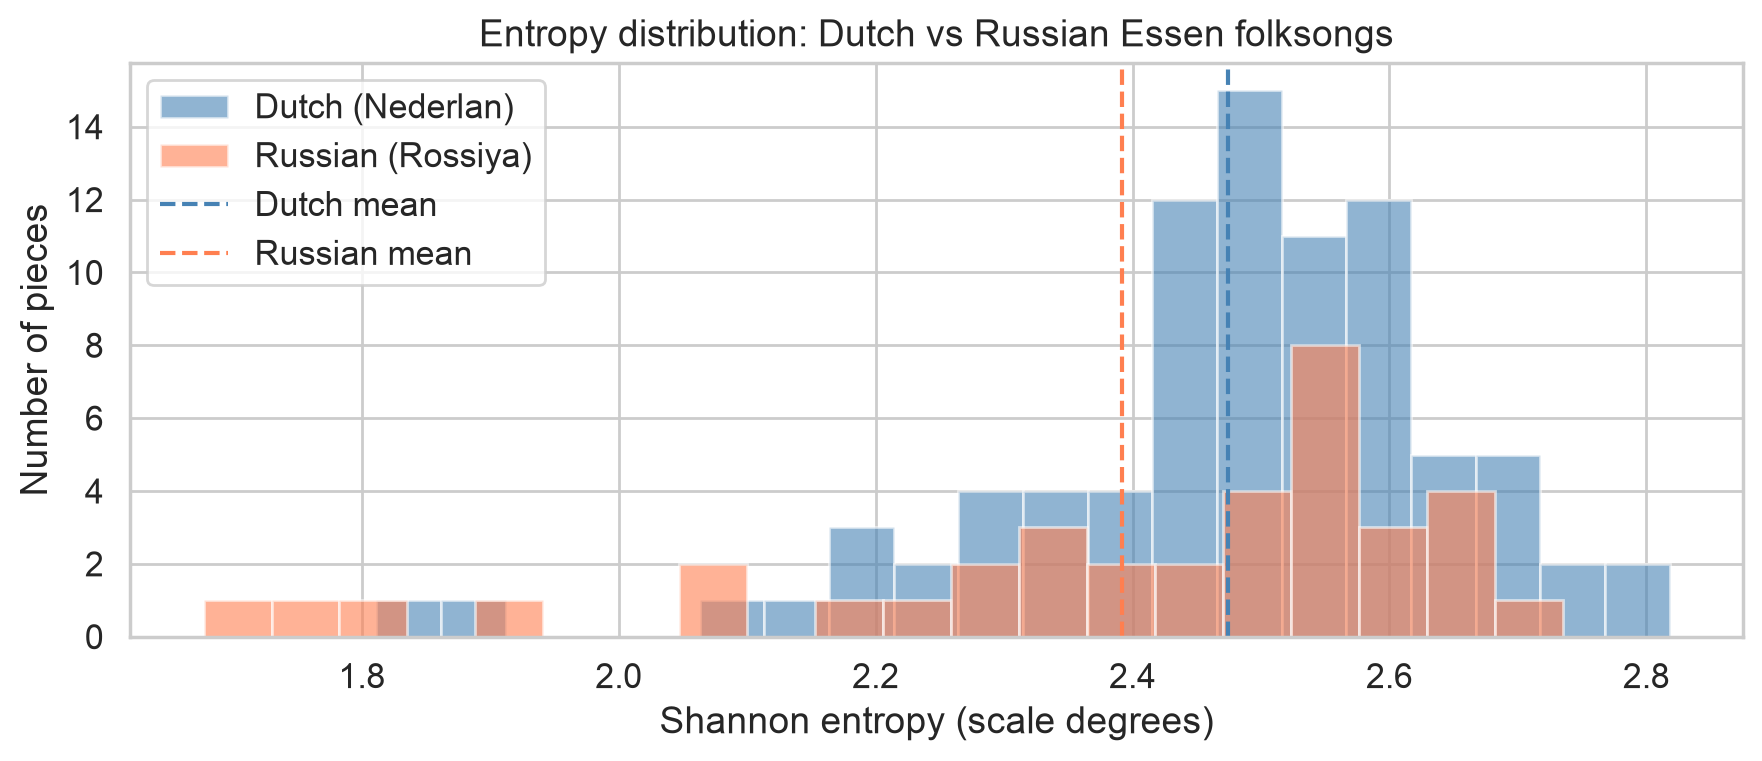

In [6]:

from utils import corpus_entropy_profile
from scipy.stats import ttest_ind

###loading the corpora
dutch = corpus_entropy_profile(
    '../data/Essen/Nederlan',
    representation='scale_degree',
    pattern='**/*.krn',
    verbose=False, plot=False)
rossiya = corpus_entropy_profile(
    '../data/Essen/Rossiya',
    representation='scale_degree',
    verbose=False, plot=False)

###running the t-test
t, p = ttest_ind(dutch['entropy'].dropna(),
                  rossiya['entropy'].dropna())

###printing the results
print(f'Dutch folk  -- mean entropy: {dutch["entropy"].mean():.3f}, '
      f'SD: {dutch["entropy"].std():.3f}, n={len(dutch)}')
print(f'Russian folk -- mean entropy: {rossiya["entropy"].mean():.3f}, '
      f'SD: {rossiya["entropy"].std():.3f}, n={len(rossiya)}')
print()
print(f't = {t:.3f}')
print(f'p = {p:.4f}')

# These are all plotting functions!
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dutch['entropy'].dropna(), bins=20, alpha=0.6,
        label='Dutch (Nederlan)', color='steelblue')
ax.hist(rossiya['entropy'].dropna(), bins=20, alpha=0.6,
        label='Russian (Rossiya)', color='coral')
ax.axvline(dutch['entropy'].mean(), color='steelblue',
           linestyle='--', label='Dutch mean')
ax.axvline(rossiya['entropy'].mean(), color='coral',
           linestyle='--', label='Russian mean')
ax.set_xlabel('Shannon entropy (scale degrees)')
ax.set_ylabel('Number of pieces')
ax.set_title('Entropy distribution: Dutch vs Russian Essen folksongs')
ax.legend()
plt.tight_layout()
plt.show()


## Exercise: 

Work through two corpora, state your hypothesis _a priori_, state your null hypothesis, and work through the code.


In [7]:
### your code here!


## Part 3: Entropy Over Time -- The Diachronic Hypothesis

Hiller and Bean (1966) analyzed sonata expositions by Mozart,
Beethoven, Berg, and Hindemith and found entropy increased
chronologically. This is one of the most cited results in
information-theoretic musicology.

**H1: Entropy (scale degree) increases significantly over time in the
Western art music corpus.**

**H0: No significant linear relationship between year and entropy.**

Before running any analysis, write your predictions:

1. Direction of slope: positive or negative?
2. Expected r² strength: weak (<0.1), moderate (0.1-0.3), strong (>0.3)?
3. Which representation will show the strongest trend?
4. Will folk music show the same diachronic trend?

*(Write predictions here before running)*


In [8]:
# Diachronic entropy using approximate midpoint dates per composer
# More reliable than kern header dates, which are inconsistently encoded

import glob
from utils import corpus_entropy_profile
COMPOSER_CORPORA = {
    'Machaut':   ('../data/humdrum_scores/Machaut',                  1360),
    'Corelli':   ('../data/humdrum_scores/Corelli',                  1683),
    'Bach':      ('../data/humdrum_scores/Bach/ArtFugue',            1717),
    'Haydn':     ('../data/humdrum_scores/Haydn/Quartets.all',       1776),
    'Mozart':    ('../data/humdrum_scores/Mozart/Quartets.Str',      1773),
    'Beethoven': ('../data/humdrum_scores/Beethoven/Quartets.Str',   1798),
    'Chopin':    ('../data/humdrum_scores/Chopin/Preludes',          1829),
}
rows = []
for composer, (kern_dir, midyear) in COMPOSER_CORPORA.items():
    print(f'Computing entropy for {composer}...')
    profile = corpus_entropy_profile(
        kern_dir,
        representation='scale_degree',
        verbose=False, plot=False)
    profile['composer'] = composer
    profile['year'] = midyear
    rows.append(profile)

classical_results = pd.concat(rows, ignore_index=True)
print(f'\nTotal pieces: {len(classical_results)}')
classical_results.head(10)

Computing entropy for Machaut...
14 piece(s) — entropy (scale_degree): mean=2.829, median=2.883, min=2.607, max=2.910
Computing entropy for Corelli...
Skipped 1 unreadable file(s).
46 piece(s) — entropy (scale_degree): mean=2.880, median=2.882, min=2.555, max=2.964
Computing entropy for Bach...
Skipped 1 unreadable file(s).
15 piece(s) — entropy (scale_degree): mean=2.958, median=2.964, min=2.921, max=2.981
Computing entropy for Haydn...
208 piece(s) — entropy (scale_degree): mean=2.906, median=2.929, min=2.459, max=2.987
Computing entropy for Mozart...
64 piece(s) — entropy (scale_degree): mean=2.903, median=2.910, min=2.724, max=2.979
Computing entropy for Beethoven...
58 piece(s) — entropy (scale_degree): mean=2.920, median=2.924, min=2.796, max=2.981
Computing entropy for Chopin...
24 piece(s) — entropy (scale_degree): mean=2.815, median=2.851, min=2.394, max=2.966

Total pieces: 429


,tune_id,entropy,n_notes,composer,year
0,machaut02,2.901310,167,Machaut,1360
1,machaut03,2.909783,197,Machaut,1360
2,machaut04,2.907344,143,Machaut,1360
3,machaut05,2.606736,174,Machaut,1360
4,machaut06,2.635393,157,Machaut,1360
5,machaut12,2.878572,116,Machaut,1360
6,machaut20,2.889022,138,Machaut,1360
7,machaut24,2.894842,134,Machaut,1360
8,machaut26,2.750879,116,Machaut,1360
9,machaut28,2.822437,157,Machaut,1360


slope         0.00013 bits/year
intercept       2.676
r               0.140
r²              0.020
p              0.0036
std error     0.00004


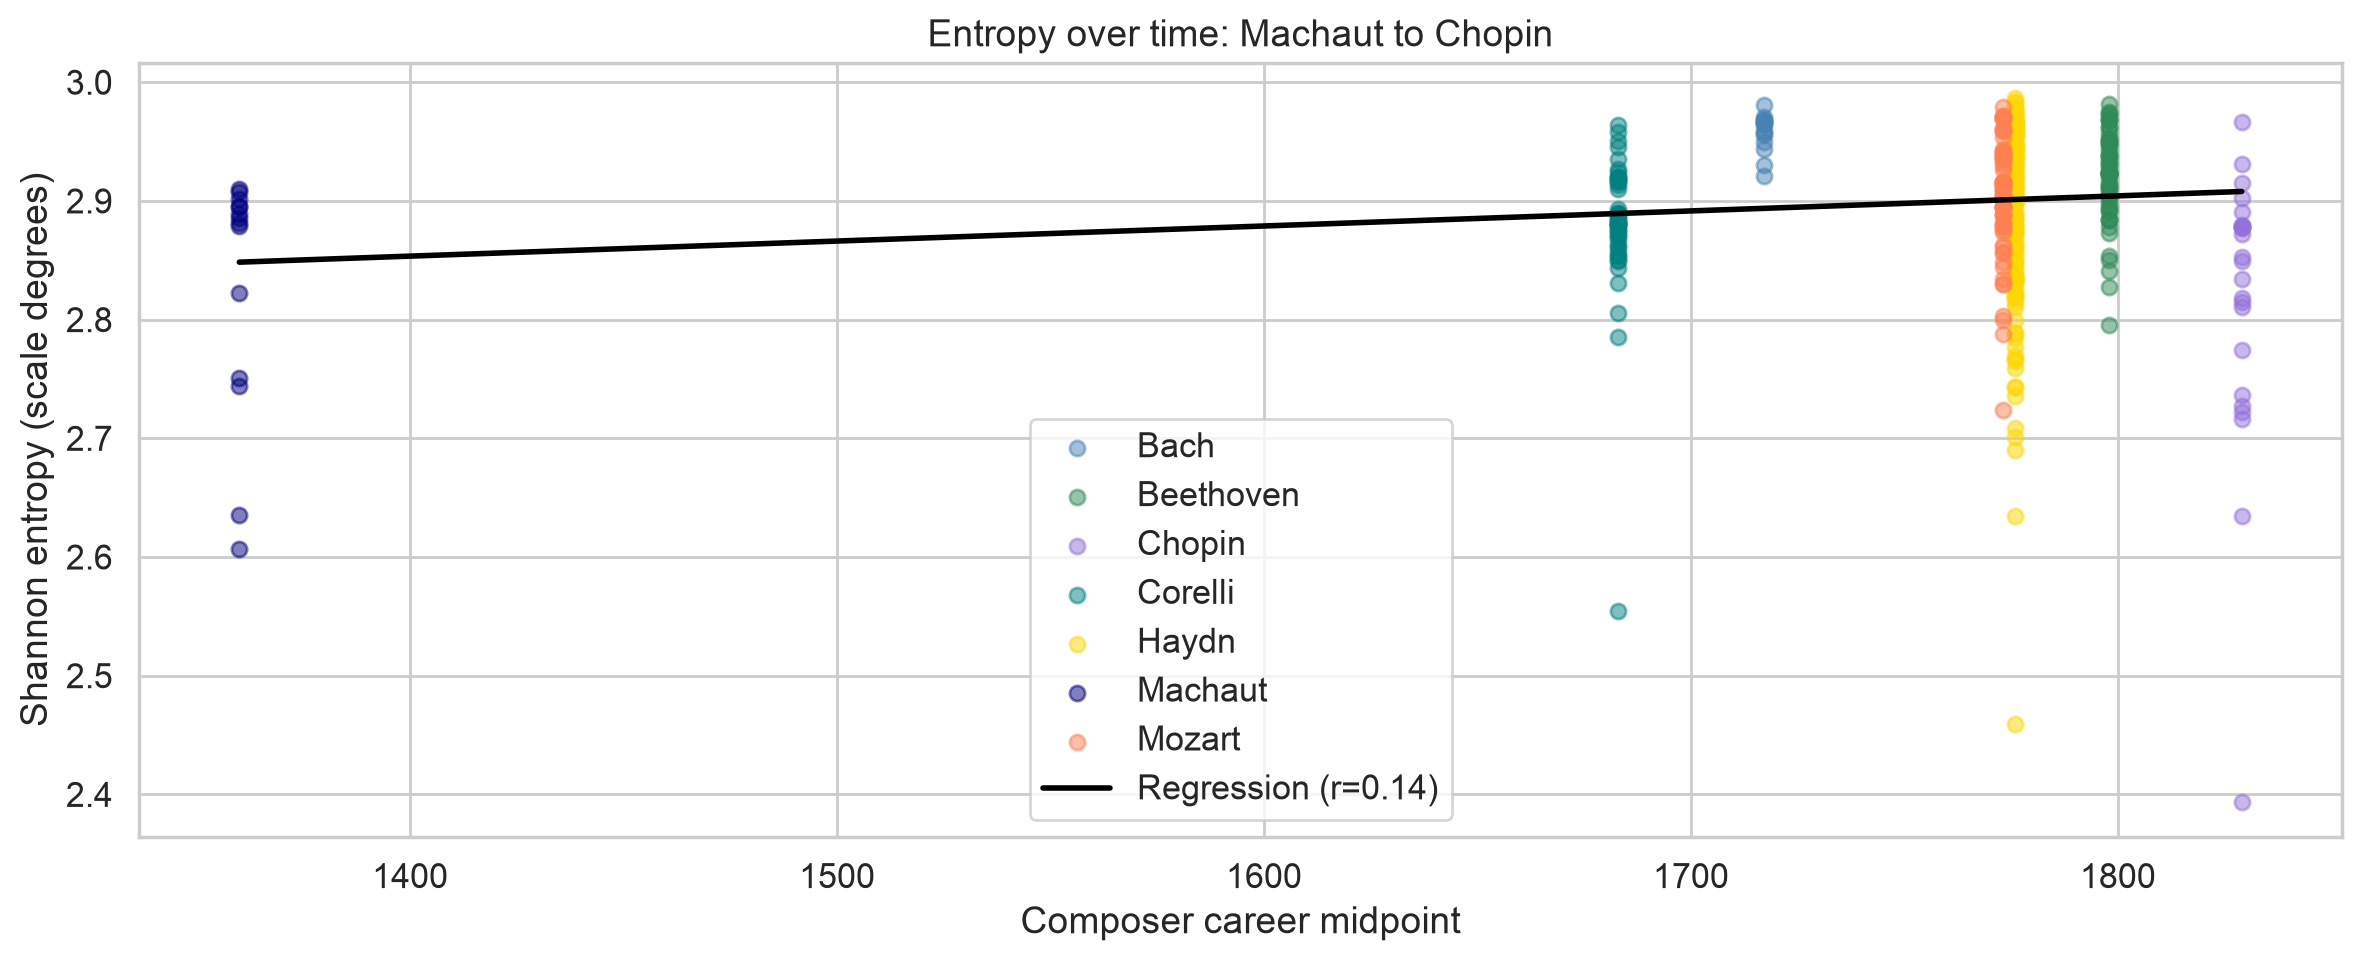

In [9]:
# Test H1 with a linear regression: does entropy increase over time?
from scipy.stats import linregress

valid = classical_results.dropna(subset=['year', 'entropy'])
slope, intercept, r, p, se = linregress(valid['year'], valid['entropy'])

print(f'slope      {slope:>10.5f} bits/year')
print(f'intercept  {intercept:>10.3f}')
print(f'r          {r:>10.3f}')
print(f'r²         {r**2:>10.3f}')
print(f'p          {p:>10.4f}')
print(f'std error  {se:>10.5f}')

# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(12, 5))
colors = {
    'Machaut':   'navy',
    'Corelli':   'teal',
    'Bach':      'steelblue',
    'Haydn':     'gold',
    'Mozart':    'coral',
    'Beethoven': 'seagreen',
    'Chopin':    'mediumpurple',
}
for composer, group in valid.groupby('composer'):
    ax.scatter(group['year'], group['entropy'],
               label=composer, alpha=0.5,
               color=colors.get(composer, 'gray'), s=30)

x_range = np.linspace(valid['year'].min(), valid['year'].max(), 100)
ax.plot(x_range, slope * x_range + intercept,
        color='black', linewidth=2, label=f'Regression (r={r:.2f})')
ax.set_xlabel('Composer career midpoint')
ax.set_ylabel('Shannon entropy (scale degrees)')
ax.set_title('Entropy over time: Machaut to Chopin')
ax.legend()
plt.tight_layout()
plt.show()

### Reading the regression: what these numbers mean for this corpus

A positive slope here means scale-degree entropy crept upward, in bits
per year, as you move from Machaut through Chopin; a negative slope means
it crept downward. 

- The size of r tells you how tightly year and
entropy track together across these composers. 
- Closer to 0means knowing the year barely predicts entropy, closer to +-1 means
they move together closely. 
- r² turns that into a share of the variance: how much of the piece-to-piece spread in entropy this single
linear trend with year actually accounts for, leaving the rest to
composer, genre, and chance.
- The p-value tells you how surprising this
slope would be if year and entropy were really unrelated -- a small p
means the trend is unlikely to be a fluke of this particular sample.


## Discussion




## Part 4: TF-IDF -- What's Distinctive, Not Just Frequent

![tf-idf.png](../images/tf-idf.png)

Shannon entropy tells you how unpredictable a corpus is internally. It
does NOT tell you what's distinctive about that corpus compared to
others.

Two corpora can have identical entropy but completely different
melodic fingerprints. Entropy is a summary statistic; TF-IDF is a
fingerprint.

**TF (Term Frequency):** how often does this n-gram appear in this
corpus?

**IDF (Inverse Document Frequency):** how rare is this n-gram across
ALL corpora?

**TF-IDF = TF x IDF:** high when common in this corpus but rare
elsewhere -- distinctive.

As a way of illustrating, we get one result with raw counts of Taylor Swift lyrics:


![](../images/swift_words_raw_counts.png)

And another, perhaps more useful result, with TF-IDF:


![](../images/swift_words_tfidf.png)



### TF-IDF for Harmonic Progressions

Imagine three corpora: Bach chorales, Beethoven quartets, Chopin
mazurkas.

**I→V** appears in all three -- high TF in each, but IDF is near zero
(it appears everywhere). TF-IDF ≈ 0. Common but not distinctive.

**I→♭VII** appears frequently in Beethoven but rarely in Bach or
Chopin. High TF for Beethoven, high IDF. TF-IDF is high. A Beethoven
fingerprint.

**I→♭II** (the Neapolitan) appears in Chopin mazurkas more than
anywhere else. TF-IDF is highest for Chopin. This matches what music
theorists already know -- Chopin loves the Neapolitan.

The test: does TF-IDF find things music theorists already know? If
yes, we can trust it for things they don't know yet.

Let's try this with some Bach chorales.

In [10]:
# Simple two-corpus distinctiveness: what does Parker play that Dizzy doesn't?
# This is the lighter version of TF-IDF students can see the logic clearly
from utils import extract_scale_degree_bigrams, distinctive_ngrams

parker_files = sorted(glob.glob('../data/charlie_parker_no_chords/*.krn'))
dizzy_files  = sorted(glob.glob('../data/dizzy_gillespie_no_chords/*.krn'))

parker_counter, _ = extract_scale_degree_bigrams(parker_files, 'Parker')
dizzy_counter, _  = extract_scale_degree_bigrams(dizzy_files, 'Dizzy')

parker_dist, dizzy_dist = distinctive_ngrams(
    parker_counter, dizzy_counter,
    name_a='Parker', name_b='Dizzy', top_n=10)

print('Most distinctive to Charlie Parker:')
display(parker_dist)
print('Most distinctive to Dizzy Gillespie:')
display(dizzy_dist)


Most distinctive to Parker:
   ngram   freq_a   freq_b  distinctiveness
  (6, 4) 0.007329 0.001669         0.814529
 (b6, 4) 0.007251 0.002276         0.761105
 (3, b2) 0.001891 0.000607         0.757086
(#4, b3) 0.002680 0.000910         0.746420
 (3, #4) 0.002404 0.000910         0.725314
 (b6, 7) 0.001970 0.000759         0.722009
(b7, #4) 0.002640 0.001062         0.713132
  (2, 3) 0.013753 0.005917         0.699175
  (1, 6) 0.018205 0.007890         0.697661
 (#4, 2) 0.002798 0.001214         0.697432

Most distinctive to Dizzy:
   ngram   freq_a   freq_b  distinctiveness
  (7, 4) 0.000276 0.001821         0.868428
(#4, b7) 0.000355 0.002124         0.856924
 (7, b3) 0.000552 0.002579         0.823798
(b3, b2) 0.002167 0.010014         0.822074
 (b7, 4) 0.001143 0.005007         0.814172
(b7, b3) 0.000906 0.003945         0.813170
 (b2, 7) 0.002837 0.011531         0.802534
 (b2, 4) 0.000906 0.003641         0.800704
(b2, b6) 0.000236 0.000910         0.793825
 (b3, 4) 0.004768 0.

,ngram,freq_a,freq_b,distinctiveness
0,"(6, 4)",0.007329,0.001669,0.814529
1,"(b6, 4)",0.007251,0.002276,0.761105
2,"(3, b2)",0.001891,0.000607,0.757086
3,"(#4, b3)",0.002680,0.000910,0.746420
4,"(3, #4)",0.002404,0.000910,0.725314
5,"(b6, 7)",0.001970,0.000759,0.722009
6,"(b7, #4)",0.002640,0.001062,0.713132
7,"(2, 3)",0.013753,0.005917,0.699175
8,"(1, 6)",0.018205,0.007890,0.697661
9,"(#4, 2)",0.002798,0.001214,0.697432


Most distinctive to Dizzy Gillespie:


,ngram,freq_a,freq_b,distinctiveness
0,"(7, 4)",0.000276,0.001821,0.868428
1,"(#4, b7)",0.000355,0.002124,0.856924
2,"(7, b3)",0.000552,0.002579,0.823798
3,"(b3, b2)",0.002167,0.010014,0.822074
4,"(b7, 4)",0.001143,0.005007,0.814172
5,"(b7, b3)",0.000906,0.003945,0.813170
6,"(b2, 7)",0.002837,0.011531,0.802534
7,"(b2, 4)",0.000906,0.003641,0.800704
8,"(b2, b6)",0.000236,0.000910,0.793825
9,"(b3, 4)",0.004768,0.016689,0.777789


### Reading the distinctiveness table

Each row shows a scale-degree bigram and how much more common it is in
one corpus than the other. **A score near 1.0 means the bigram almost
exclusively appears in that corpus. Near 0.5 means equal frequency in
both.**

Do these results map onto what you might expect?




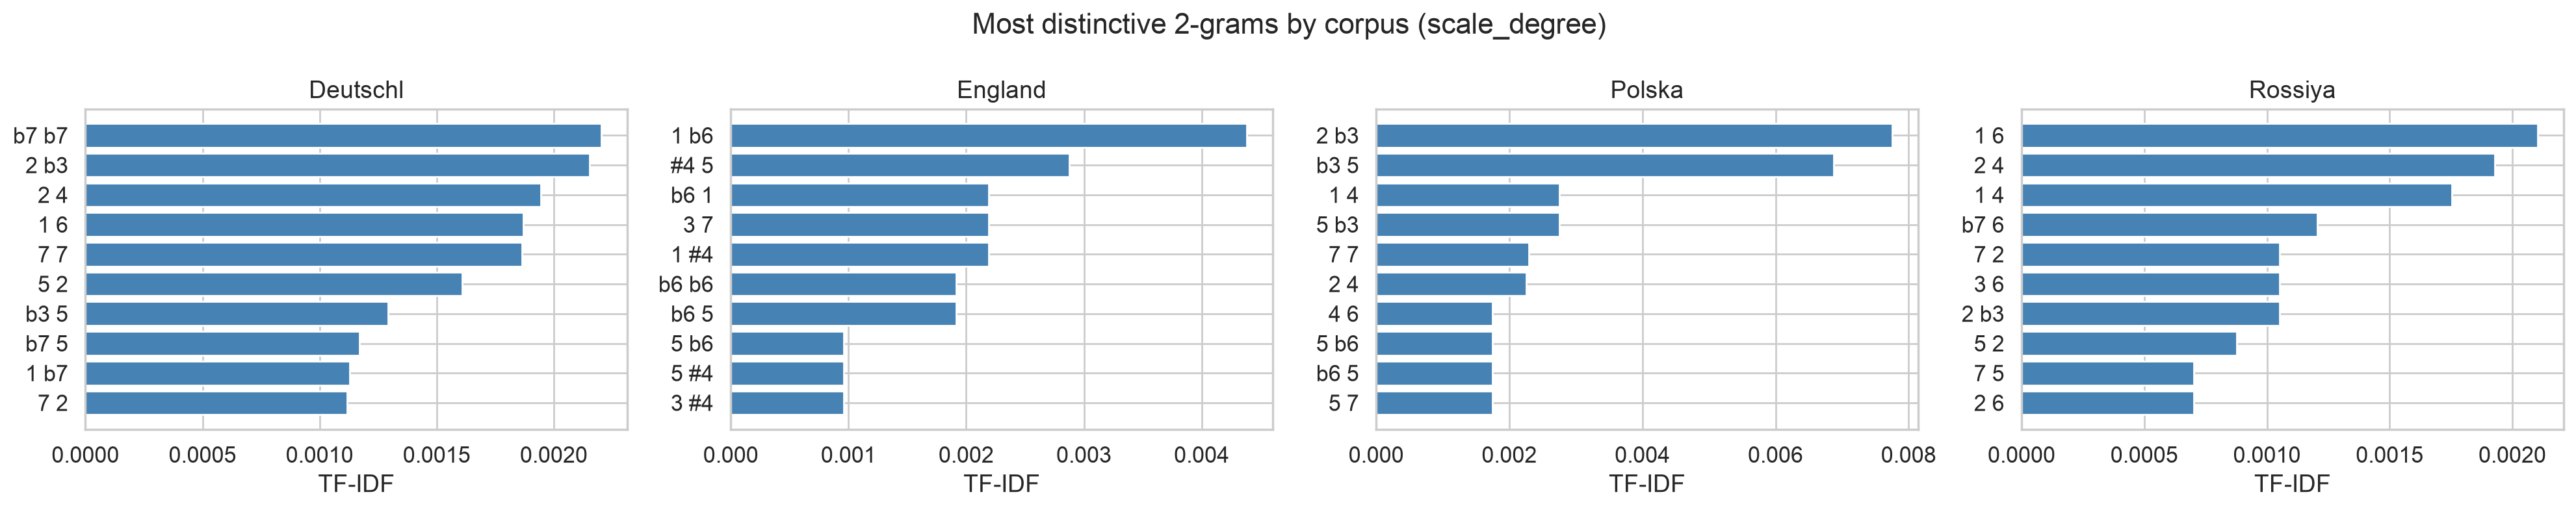

,corpus,ngram,tf,idf,tfidf
0,Deutschl,"(b7, b7)",0.002405,0.916291,0.002204
1,Deutschl,"(2, b3)",0.009644,0.223144,0.002152
2,Deutschl,"(2, 4)",0.008718,0.223144,0.001945
3,Deutschl,"(1, 6)",0.008383,0.223144,0.001871
4,Deutschl,"(7, 7)",0.003650,0.510826,0.001865
5,Deutschl,"(5, 2)",0.007208,0.223144,0.001608
6,Deutschl,"(b3, 5)",0.002532,0.510826,0.001294
7,Deutschl,"(b7, 5)",0.002289,0.510826,0.001170
8,Deutschl,"(1, b7)",0.005057,0.223144,0.001128
9,Deutschl,"(7, 2)",0.005011,0.223144,0.001118


In [11]:

# quick note about glob: Deutschl is organized into sub-collections rather than one flat
# folder (see Exercise 2A), so its file list needs a recursive glob. 
# It's also super slow becuase the corpus is so biased in that direction. 
# If we want to be quicker we should just avoid that line.

from utils import tf_idf_ngrams

essen_tfidf = tf_idf_ngrams({
    'England':  sorted(glob.glob('../data/Essen/England/*.krn')),
    'Polska':   sorted(glob.glob('../data/Essen/Polska/*.krn')),
    'Rossiya':  sorted(glob.glob('../data/Essen/Rossiya/*.krn')),
    'Deutschl': sorted(glob.glob('../data/Essen/Deutschl/**/*.krn', recursive=True)),
}, n=2, top_n=10, representation='scale_degree',
   plot=True, verbose=False)

essen_tfidf.head(20)


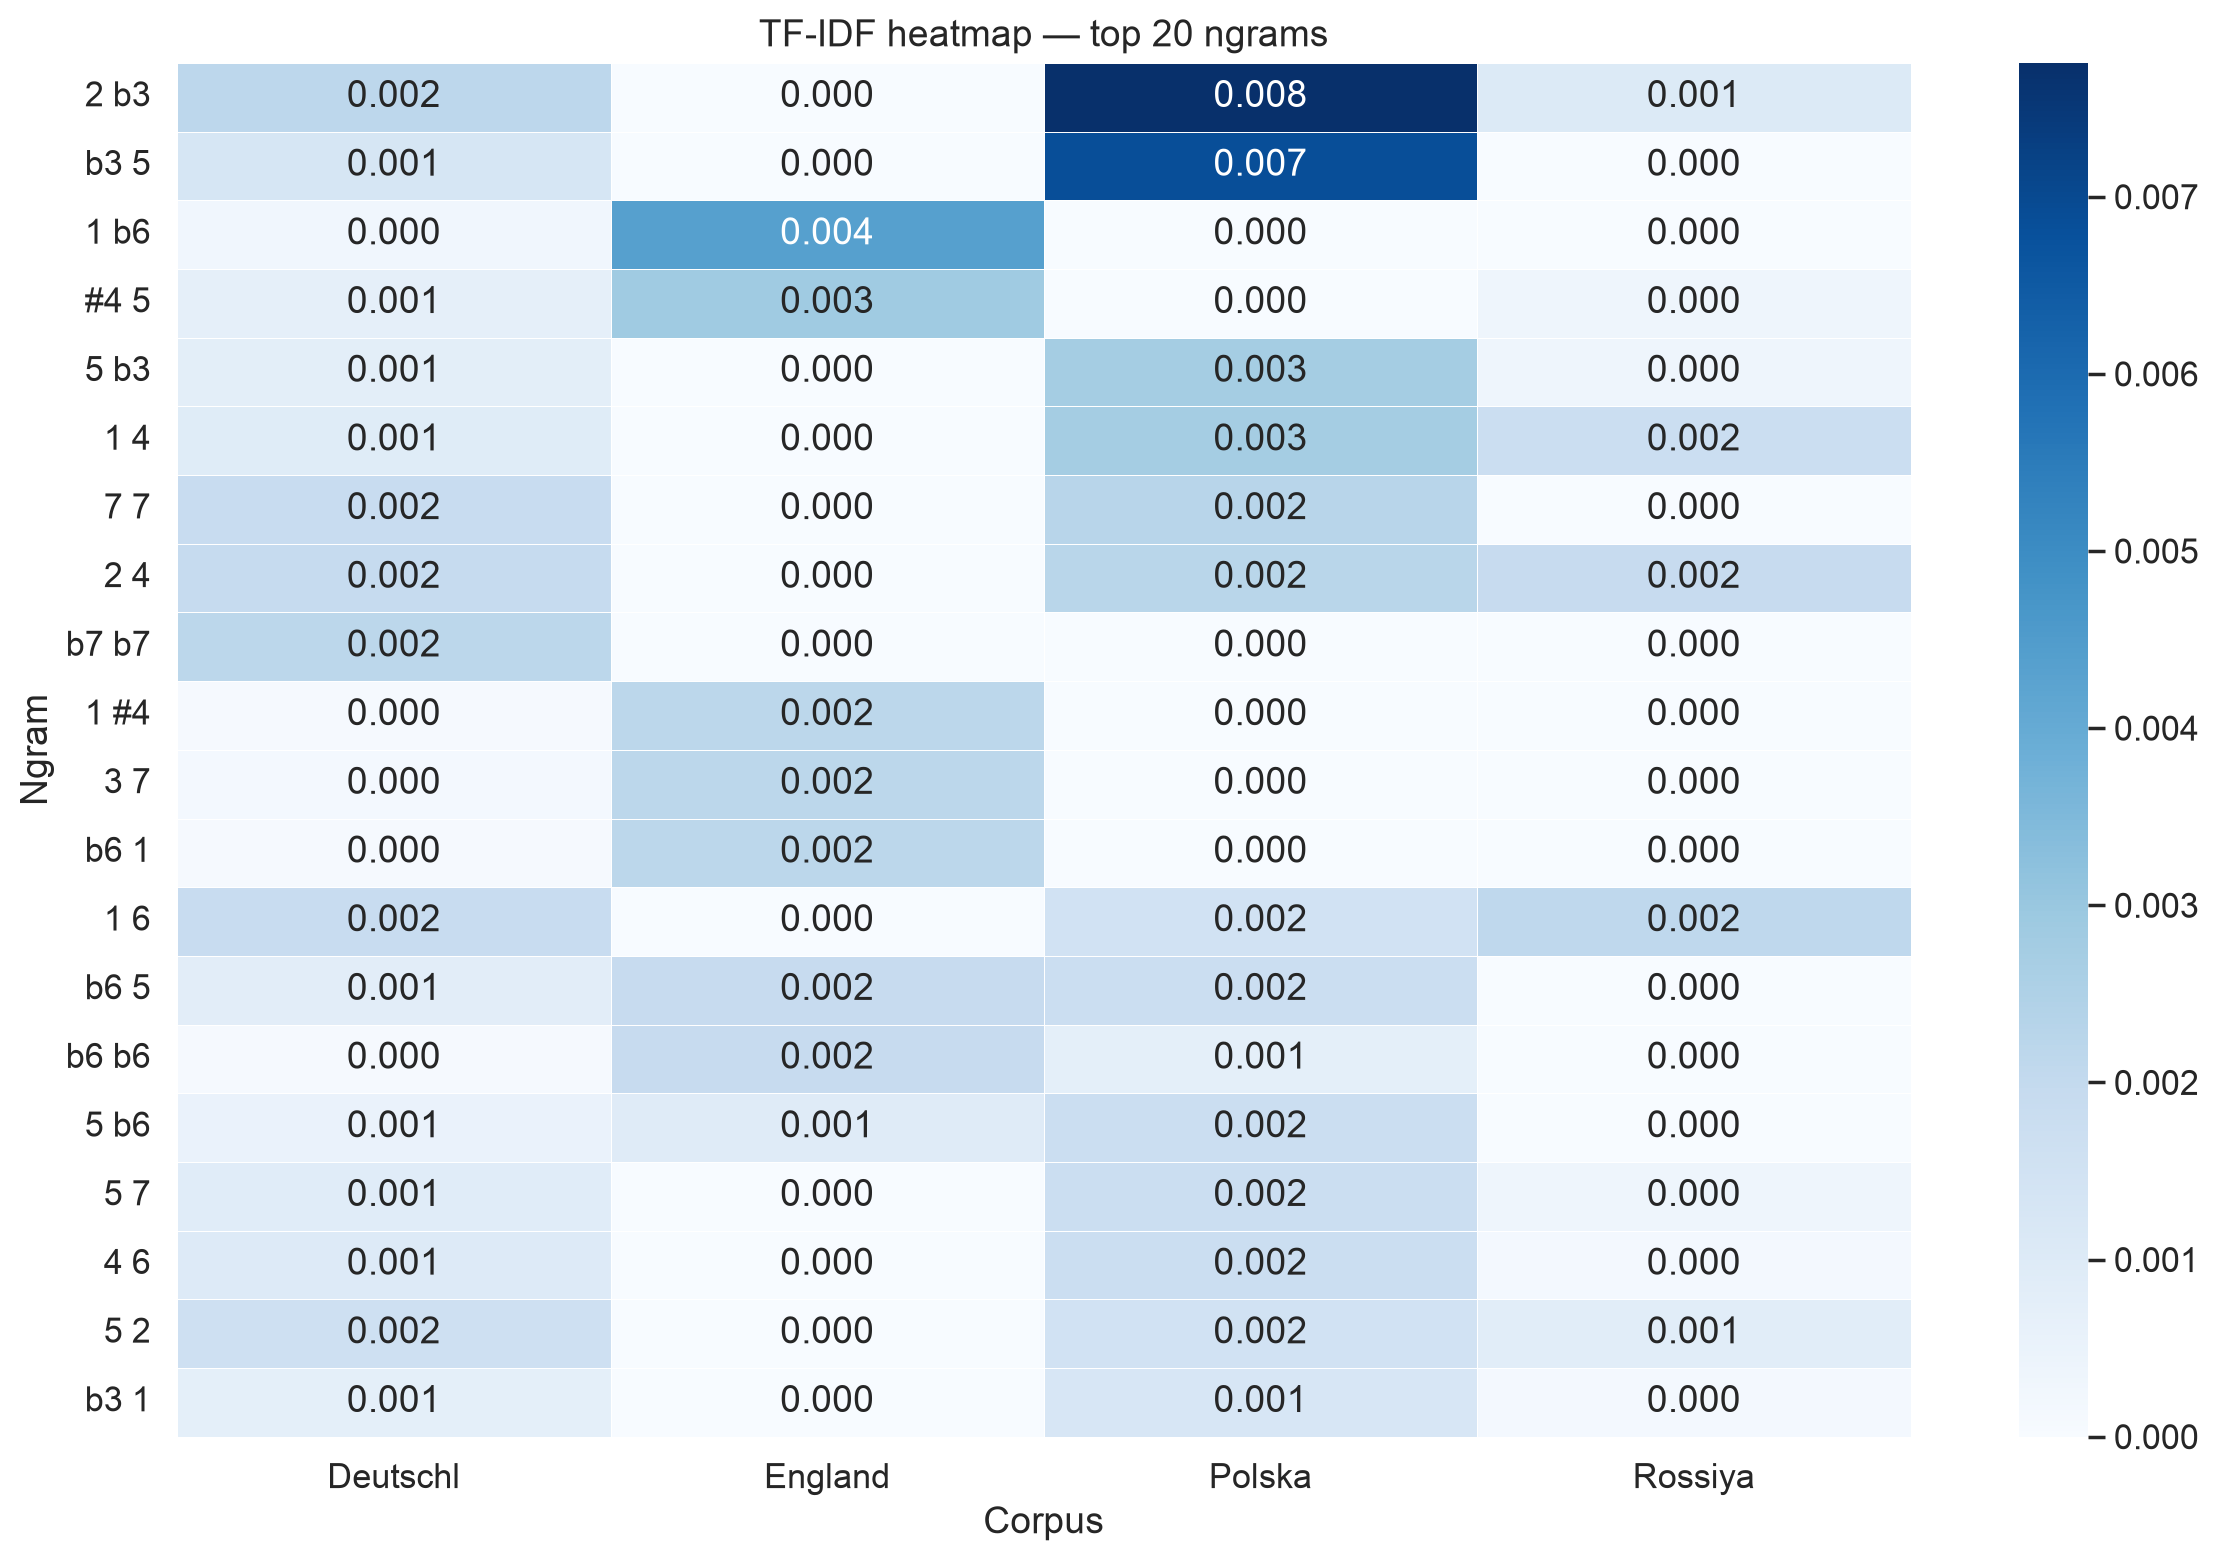

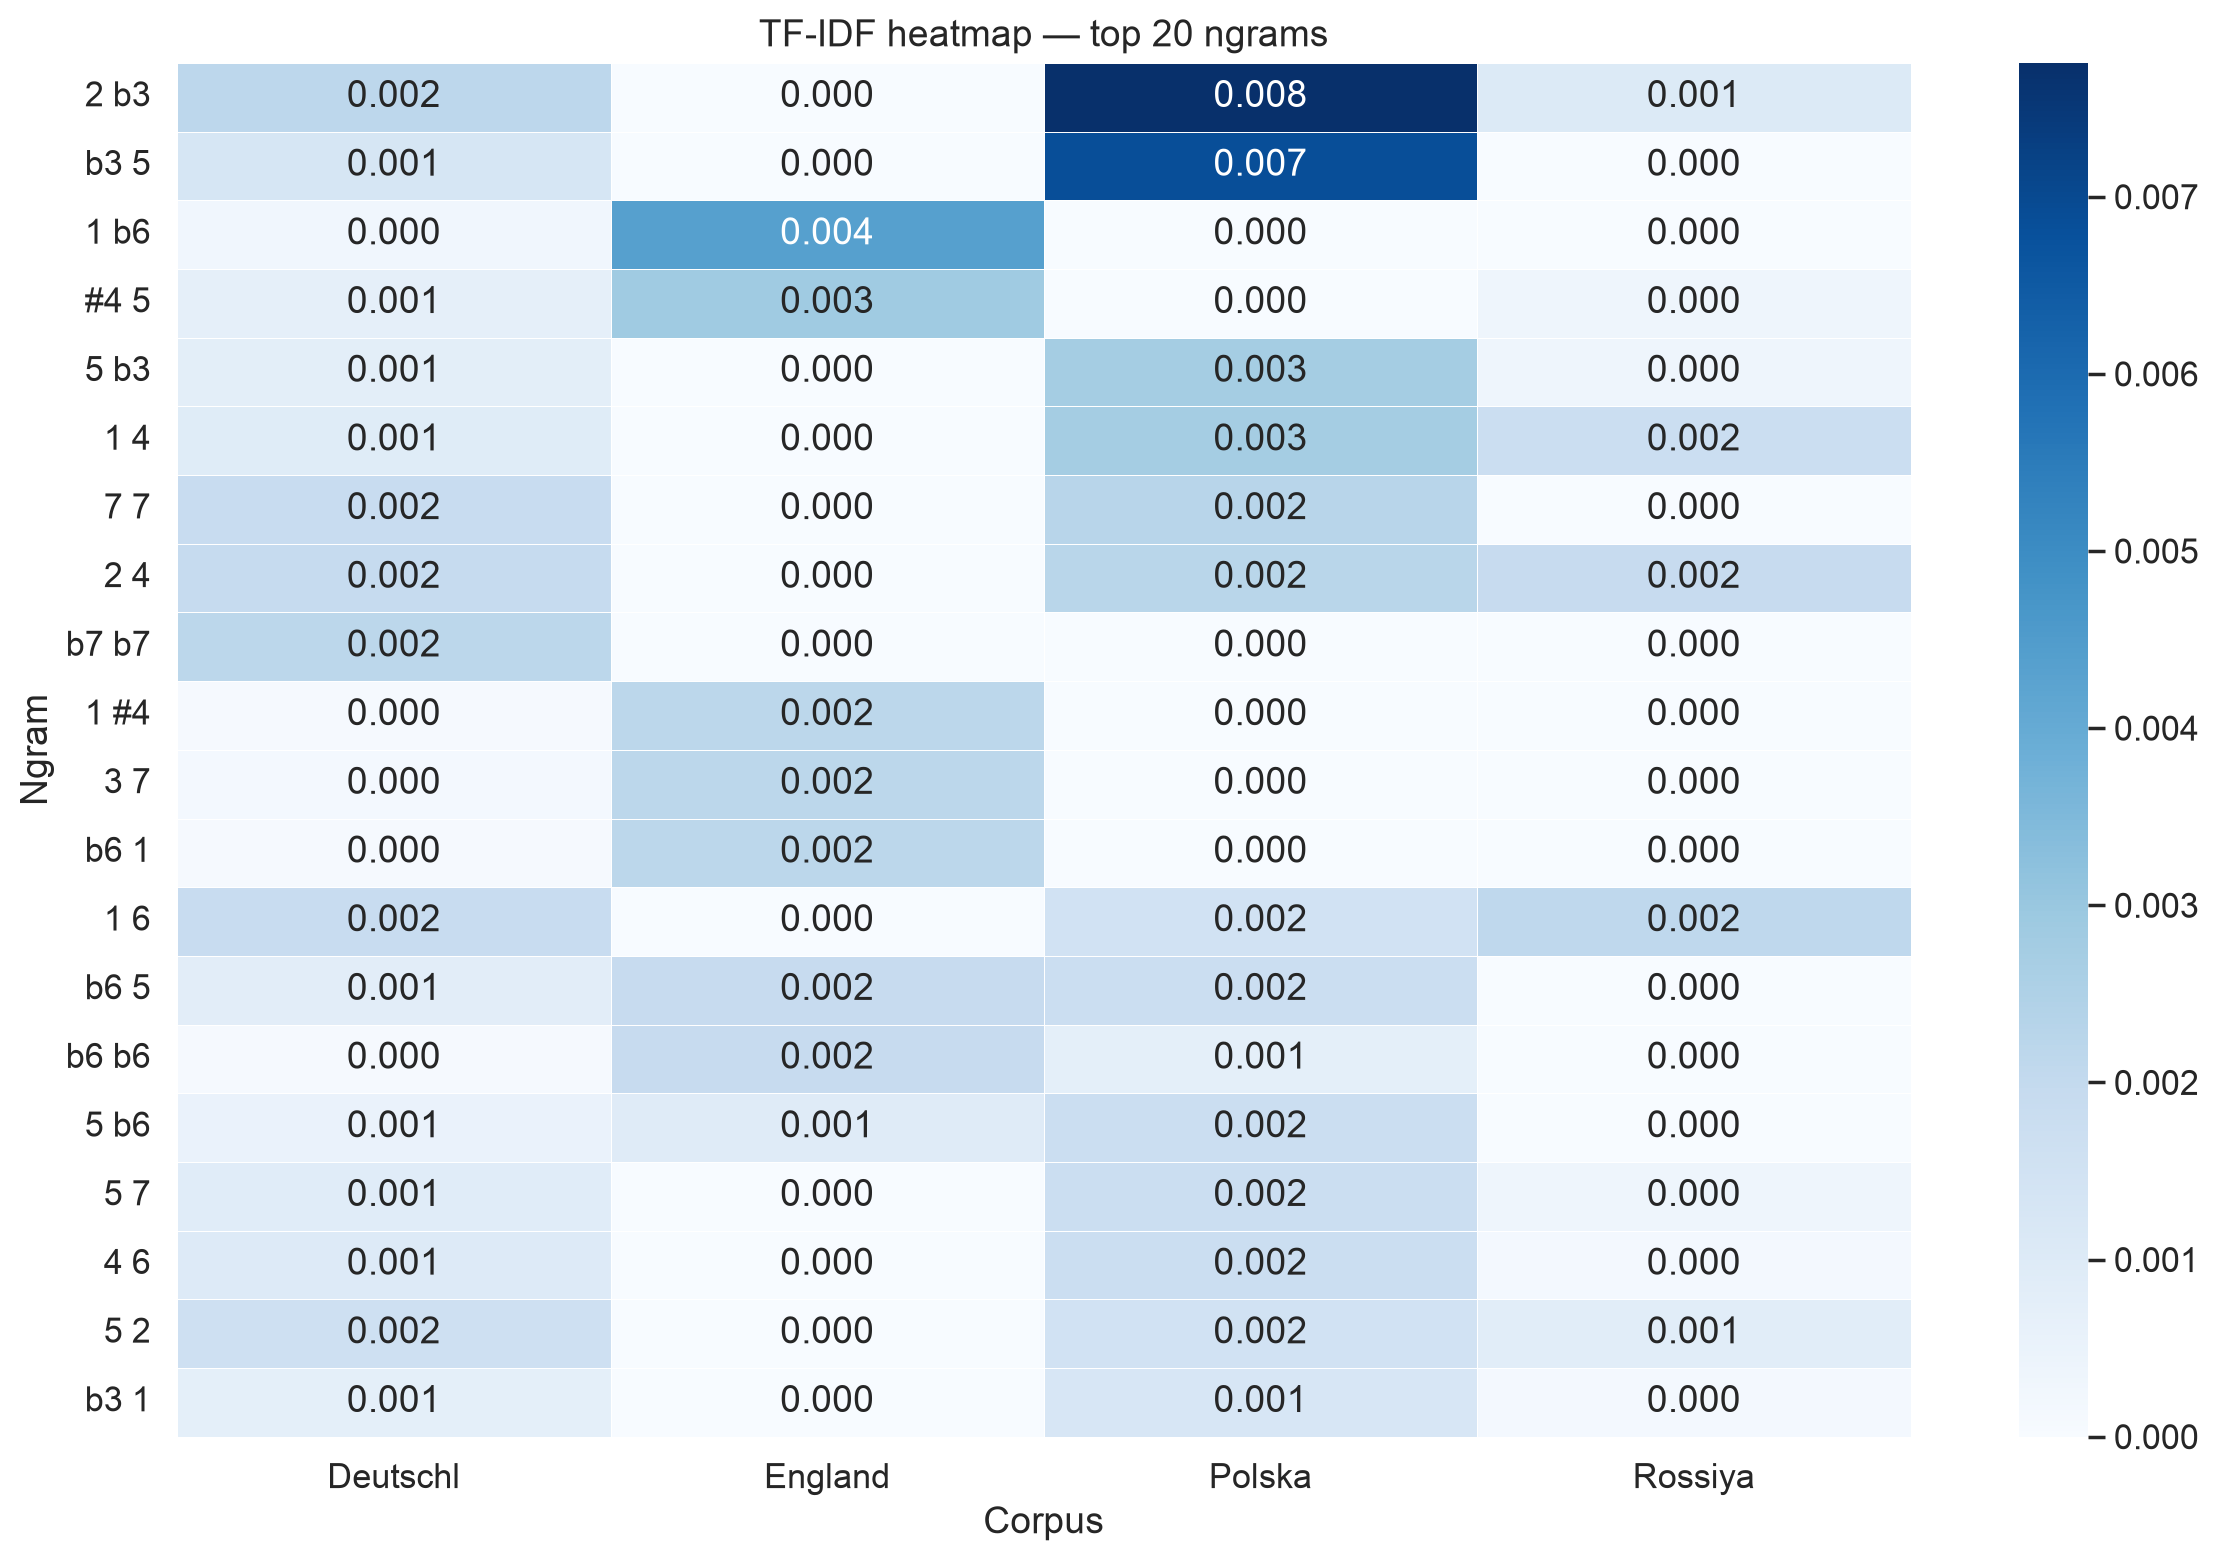

In [12]:
# Heatmap view: which patterns belong to which tradition at a glance
from utils import plot_tfidf_heatmap

plot_tfidf_heatmap(essen_tfidf, top_n=20)


### Exercise: TF-IDF as Stylistic Argument

Run `tf_idf_ngrams` on three Essen regions you haven't analyzed yet
(change the CHANGEME markers below).

Find the single highest TF-IDF bigram for each region. Look at the
actual scale degrees -- what two scale degrees does it connect? Is
that a musically meaningful transition for that tradition?




In [13]:
# Change the three CHANGEME paths to Essen regions you haven't tried yet
# Available: Sverige, Italia, France, Magyar, Ukraina, Oesterrh, etc.
your_tfidf = tf_idf_ngrams({
    'CHANGEME1': sorted(glob.glob('../data/Essen/CHANGEME1/*.krn')),
    'CHANGEME2': sorted(glob.glob('../data/Essen/CHANGEME2/*.krn')),
    'CHANGEME3': sorted(glob.glob('../data/Essen/CHANGEME3/*.krn')),
}, n=2, top_n=5, representation='scale_degree',
   plot=True, verbose=False)

for corpus in your_tfidf['corpus'].unique():
    top_row = your_tfidf[your_tfidf['corpus'] == corpus].iloc[0]
    print(f'{corpus}: top bigram = {top_row["ngram"]}, TF-IDF = {top_row["tfidf"]:.4f}')


KeyError: 'corpus'

### Discussion!

- What were your results?
- Are there any interesting points about it?


## TF-IDF on Harmonic Progressions

So far we have applied TF-IDF to melodic n-grams -- sequences of
scale degrees or intervals. The same logic applies to harmony:
what chord progressions are distinctive to one composer compared
to others?

We use music21's `chordify()` to reduce each kern file to a
sequence of vertical sonorities, then extract Roman numeral
labels relative to the detected key. The resulting bigrams
(pairs of Roman numerals) can be compared with the same
distinctive_ngrams and tf_idf framework we already used for melody.


In [ ]:
# Extract Roman numeral bigrams from kern files via music21 chordify
# Each file is chordified, analyzed for key, and converted to RN sequence
from music21 import converter, roman
from collections import Counter
import glob

def extract_roman_numeral_bigrams(kern_dir, composer_name, verbose=True):
    """
    Chordify all kern files in a directory and extract Roman numeral bigrams.

    Uses music21's chordify() to reduce each score to vertical sonorities,
    detects the key, then maps each chord to a Roman numeral label.
    Bigrams are pairs of consecutive Roman numeral labels.

    Parameters:
    kern_dir : str
        Path to directory containing .krn files. Searches recursively.
    composer_name : str
        Label used in progress messages.
    verbose : bool
        Print progress every 10 files.

    Returns a counter of of (RN1, RN2) tuples.

    Usage
    -----
        bach_harm = extract_roman_numeral_bigrams(
            '../data/humdrum_scores/Bach/ArtFugue', 'Bach')
    """
    files = sorted(glob.glob(f'{kern_dir}/**/*.krn', recursive=True))
    if not files:
        files = sorted(glob.glob(f'{kern_dir}/*.krn'))
    if not files:
        print(f'No kern files found in {kern_dir}')
        return Counter()
    all_bigrams = []
    skipped = 0
    for i, f in enumerate(files):
        if verbose and i % 10 == 0:
            print(f'  {composer_name}: {i+1}/{len(files)}...')
        try:
            score = converter.parse(f)
            k = score.analyze('key')
            chordified = score.chordify()
            rn_seq = []
            for ch in chordified.recurse().getElementsByClass('Chord'):
                try:
                    rn = roman.romanNumeralFromChord(ch, k)
                    rn_seq.append(rn.romanNumeral)
                except Exception:
                    continue
            all_bigrams.extend(zip(rn_seq, rn_seq[1:]))
        except Exception:
            skipped += 1
            continue
    if verbose:
        print(f'  {composer_name}: done -- '
              f'{len(files) - skipped} files, '
              f'{len(all_bigrams)} bigrams, '
              f'{skipped} skipped\n')
    return Counter(all_bigrams)

In [ ]:
# Extract Roman numeral bigrams for Bach, Mozart, Beethoven, Chopin
# Uses the same corpus paths as the diachronic analysis above
# Warning: chordify is slow -- this cell may take 3-5 minutes
print('Extracting harmonic bigrams via chordify...')
print('This may take a few minutes.\n')

bach_harm      = extract_roman_numeral_bigrams(
    '../data/humdrum_scores/Bach/ArtFugue',          'Bach')
mozart_harm    = extract_roman_numeral_bigrams(
    '../data/humdrum_scores/Mozart/Quartets.Str',    'Mozart')
beethoven_harm = extract_roman_numeral_bigrams(
    '../data/humdrum_scores/Beethoven/Quartets.Str', 'Beethoven')
chopin_harm    = extract_roman_numeral_bigrams(
    '../data/humdrum_scores/Chopin/Preludes',        'Chopin')

# Show most common progressions overall
combined = bach_harm + mozart_harm + beethoven_harm + chopin_harm
print('Top 10 Roman numeral bigrams across all four composers:')
for bigram, count in combined.most_common(10):
    print(f'  {bigram[0]}->{bigram[1]}: {count}')

Extracting harmonic bigrams via chordify...
This may take a few minutes.

  Bach: 1/16...
  Bach: 11/16...
  Bach: done -- 15 files, 12573 bigrams, 1 skipped

  Mozart: 1/64...
  Mozart: 11/64...
  Mozart: 21/64...
  Mozart: 31/64...
  Mozart: 41/64...
  Mozart: 51/64...
  Mozart: 61/64...
  Mozart: done -- 64 files, 39472 bigrams, 0 skipped

  Beethoven: 1/58...
  Beethoven: 11/58...
  Beethoven: 21/58...
  Beethoven: 31/58...
  Beethoven: 41/58...
  Beethoven: 51/58...
  Beethoven: done -- 58 files, 81957 bigrams, 0 skipped

  Chopin: 1/24...
  Chopin: 11/24...
  Chopin: 21/24...
  Chopin: done -- 24 files, 8962 bigrams, 0 skipped

Top 10 Roman numeral bigrams across all four composers:
  I->I: 6993
  V->V: 6186
  i->i: 4537
  v->v: 3731
  ii->ii: 3104
  vi->vi: 2134
  IV->IV: 2055
  iii->iii: 2009
  V->I: 1986
  iv->iv: 1967


### What to expect

The most common bigrams across all composers will almost certainly
be I->I (tonic repeating), I->V, and V->I. These will have **low TF-IDF** scores because they
appear in every composer's output. They are common, but not distinctive.

For the distinctive score, it's just whether or not it _ever_ appears in the other corpus.
So every Bach progression that never appears in Chopin gets a distinctiveness score of exactly 1.0, and vice versa (just a quick proxy).

In [ ]:
# Two-corpus distinctiveness: what harmonic moves separate Bach from Chopin?
# Same function as Parker vs Dizzy, now applied to Roman numeral bigrams
from utils import distinctive_ngrams

print('=== Bach vs Chopin: distinctive harmonic progressions ===\n')

bach_dist, chopin_dist = distinctive_ngrams(
    bach_harm, chopin_harm,
    name_a='Bach', name_b='Chopin', top_n=10)

print('Most distinctive to Bach:')
display(bach_dist)
print()
print('Most distinctive to Chopin:')
display(chopin_dist)

=== Bach vs Chopin: distinctive harmonic progressions ===

Most distinctive to Bach:
      ngram   freq_a  freq_b  distinctiveness
  (VI, VII) 0.002625     0.0              1.0
(VII, #iii) 0.002386     0.0              1.0
  (#iii, I) 0.002227     0.0              1.0
  (III, IV) 0.001909     0.0              1.0
 (IV, #vii) 0.001670     0.0              1.0
  (IV, VII) 0.001511     0.0              1.0
  (II, VII) 0.001352     0.0              1.0
   (VII, I) 0.001352     0.0              1.0
  (VII, iv) 0.001273     0.0              1.0
  (bii, VI) 0.001113     0.0              1.0

Most distinctive to Chopin:
       ngram  freq_a   freq_b  distinctiveness
    (bi, bi)     0.0 0.004575              1.0
  (biv, biv)     0.0 0.004575              1.0
(bbvi, bbvi)     0.0 0.004352              1.0
     (I, vi)     0.0 0.003794              1.0
(bbII, bbII)     0.0 0.003236              1.0
    (#V, #V)     0.0 0.003124              1.0
(bbVI, bbVI)     0.0 0.002566              1.0
 (bb

,ngram,freq_a,freq_b,distinctiveness
0,"(VI, VII)",0.002625,0.0,1.0
1,"(VII, #iii)",0.002386,0.0,1.0
2,"(#iii, I)",0.002227,0.0,1.0
3,"(III, IV)",0.001909,0.0,1.0
4,"(IV, #vii)",0.001670,0.0,1.0
5,"(IV, VII)",0.001511,0.0,1.0
6,"(II, VII)",0.001352,0.0,1.0
7,"(VII, I)",0.001352,0.0,1.0
8,"(VII, iv)",0.001273,0.0,1.0
9,"(bii, VI)",0.001113,0.0,1.0



Most distinctive to Chopin:


,ngram,freq_a,freq_b,distinctiveness
0,"(bi, bi)",0.0,0.004575,1.0
1,"(biv, biv)",0.0,0.004575,1.0
2,"(bbvi, bbvi)",0.0,0.004352,1.0
3,"(I, vi)",0.0,0.003794,1.0
4,"(bbII, bbII)",0.0,0.003236,1.0
5,"(#V, #V)",0.0,0.003124,1.0
6,"(bbVI, bbVI)",0.0,0.002566,1.0
7,"(bbII, biv)",0.0,0.002232,1.0
8,"(vi, #iv)",0.0,0.002120,1.0
9,"(bIII, bIII)",0.0,0.002120,1.0


In [ ]:
# Mozart vs Beethoven: contemporaries with different harmonic languages
print('=== Mozart vs Beethoven: distinctive harmonic progressions ===\n')

mozart_dist, beeth_dist = distinctive_ngrams(
    mozart_harm, beethoven_harm,
    name_a='Mozart', name_b='Beethoven', top_n=10)

print('Most distinctive to Mozart:')
display(mozart_dist)
print()
print('Most distinctive to Beethoven:')
display(beeth_dist)

=== Mozart vs Beethoven: distinctive harmonic progressions ===

Most distinctive to Mozart:
      ngram   freq_a  freq_b  distinctiveness
  (#vi, bv) 0.000076     0.0         0.999999
(biii, Ger) 0.000076     0.0         0.999999
   (bV, VI) 0.000076     0.0         0.999999
 (Ger, bVI) 0.000051     0.0         0.999998
   (VI, bV) 0.000051     0.0         0.999998
  (bv, #vi) 0.000051     0.0         0.999998
  (vi, Ger) 0.000051     0.0         0.999998
 (#vii, It) 0.000051     0.0         0.999998
(Ger, biii) 0.000051     0.0         0.999998
  (bVI, Fr) 0.000051     0.0         0.999998

Most distinctive to Beethoven:
       ngram  freq_a   freq_b  distinctiveness
(bbII, bbII)     0.0 0.000842              1.0
  (#iii, ii)     0.0 0.000573              1.0
  (bIV, bIV)     0.0 0.000390              1.0
    (#V, #V)     0.0 0.000342              1.0
    (bv, bv)     0.0 0.000329              1.0
   (#iii, V)     0.0 0.000293              1.0
 (bVI, biii)     0.0 0.000281            

,ngram,freq_a,freq_b,distinctiveness
0,"(#vi, bv)",0.000076,0.0,0.999999
1,"(biii, Ger)",0.000076,0.0,0.999999
2,"(bV, VI)",0.000076,0.0,0.999999
3,"(Ger, bVI)",0.000051,0.0,0.999998
4,"(VI, bV)",0.000051,0.0,0.999998
5,"(bv, #vi)",0.000051,0.0,0.999998
6,"(vi, Ger)",0.000051,0.0,0.999998
7,"(#vii, It)",0.000051,0.0,0.999998
8,"(Ger, biii)",0.000051,0.0,0.999998
9,"(bVI, Fr)",0.000051,0.0,0.999998



Most distinctive to Beethoven:


,ngram,freq_a,freq_b,distinctiveness
0,"(bbII, bbII)",0.0,0.000842,1.0
1,"(#iii, ii)",0.0,0.000573,1.0
2,"(bIV, bIV)",0.0,0.000390,1.0
3,"(#V, #V)",0.0,0.000342,1.0
4,"(bv, bv)",0.0,0.000329,1.0
5,"(#iii, V)",0.0,0.000293,1.0
6,"(bVI, biii)",0.0,0.000281,1.0
7,"(bII, bvii)",0.0,0.000244,1.0
8,"(IV, #iii)",0.0,0.000244,1.0
9,"(#ii, #iv)",0.0,0.000232,1.0


In [ ]:
composer_counters = {
    'Bach':      bach_harm,
    'Mozart':    mozart_harm,
    'Beethoven': beethoven_harm,
    'Chopin':    chopin_harm,
}

n_corp = len(composer_counters)
rows = []

all_bigrams = set()
for c in composer_counters.values():
    all_bigrams.update(c.keys())

for corpus_name, counter in composer_counters.items():
    total = sum(counter.values())
    for bigram in all_bigrams:
        tf = counter.get(bigram, 0) / total if total else 0
        df = sum(1 for c in composer_counters.values() if bigram in c)
        # No +1 at end — universal terms now get IDF=0
        idf = np.log((n_corp + 1) / (df + 1))
        tfidf = tf * idf
        if tfidf > 0:
            rows.append({
                'corpus':      corpus_name,
                'progression': f'{bigram[0]}→{bigram[1]}',
                'tf':          round(tf, 6),
                'idf':         round(idf, 3),
                'tfidf':       round(tfidf, 6),
            })

harmonic_tfidf = pd.DataFrame(rows).sort_values('tfidf', ascending=False)

# Spot check
print('i→i IDF should now be 0:')
ii = harmonic_tfidf[harmonic_tfidf.progression == 'i→i']
display(ii[['corpus','tf','idf','tfidf']])

print('\nTop distinctive progressions per composer:')
for corpus in composer_counters:
    top = (harmonic_tfidf[harmonic_tfidf.corpus == corpus]
           .head(5))
    print(f'\n{corpus}:')
    display(top[['progression','tf','idf','tfidf']].reset_index(drop=True))

i→i IDF should now be 0:


,corpus,tf,idf,tfidf



Top distinctive progressions per composer:

Bach:


,progression,tf,idf,tfidf
0,VI→VII,0.002625,0.223,0.000586
1,VII→#iii,0.002386,0.223,0.000532
2,#iii→I,0.002227,0.223,0.000497
3,I→bII,0.000875,0.511,0.000447
4,III→IV,0.001909,0.223,0.000426



Mozart:


,progression,tf,idf,tfidf
0,V→vi,0.007676,0.223,0.001713
1,I→vi,0.006080,0.223,0.001357
2,iii→V,0.005219,0.223,0.001165
3,IV→vi,0.003496,0.223,0.000780
4,V→#iv,0.003065,0.223,0.000684



Beethoven:


,progression,tf,idf,tfidf
0,I→vi,0.005295,0.223,0.001182
1,V→vi,0.005039,0.223,0.001124
2,iii→V,0.004027,0.223,0.000898
3,bVII→bVII,0.003782,0.223,0.000844
4,IV→vi,0.003526,0.223,0.000787



Chopin:


,progression,tf,idf,tfidf
0,bi→bi,0.004575,0.511,0.002337
1,biv→biv,0.004575,0.511,0.002337
2,bbvi→bbvi,0.004352,0.511,0.002223
3,bbII→bbII,0.003236,0.511,0.001653
4,#V→#V,0.003124,0.511,0.001596


In [ ]:
print('\nChopin:')
display(harmonic_tfidf[harmonic_tfidf.corpus == 'Chopin'].head(5)[
    ['progression','tf','idf','tfidf']].reset_index(drop=True))

print('\nBeethoven:')
display(harmonic_tfidf[harmonic_tfidf.corpus == 'Beethoven'].head(5)[
    ['progression','tf','idf','tfidf']].reset_index(drop=True))


Chopin:


,progression,tf,idf,tfidf
0,bi→bi,0.004575,0.511,0.002337
1,biv→biv,0.004575,0.511,0.002337
2,bbvi→bbvi,0.004352,0.511,0.002223
3,bbII→bbII,0.003236,0.511,0.001653
4,#V→#V,0.003124,0.511,0.001596



Beethoven:


,progression,tf,idf,tfidf
0,I→vi,0.005295,0.223,0.001182
1,V→vi,0.005039,0.223,0.001124
2,iii→V,0.004027,0.223,0.000898
3,bVII→bVII,0.003782,0.223,0.000844
4,IV→vi,0.003526,0.223,0.000787


## What the TF-IDF results tell us

**Bach: VI→VII, VII→#iii, I→♭II**
The chains of thirds and the approach to the Neapolitan (I→♭II) 
reflect the chromatic voice-leading of the Art of Fugue. These 
are contrapuntal progressions — they arise from independent 
melodic lines converging, not from functional harmonic planning 
in the Classical sense. A music theorist would recognize these 
immediately as characteristic of late-Baroque style.

**Mozart: V→vi, I→vi, iii→V**
The deceptive cadence (V→vi) as Mozart's most distinctive 
progression is exactly what music theory textbooks say about 
Classical style — the deceptive cadence extends phrases rather 
than closing them, creating forward momentum. I→vi (moving to 
the submediant) and the approach to V through iii are equally 
characteristic of Haydn-era voice leading.

**Chopin: ♭iv→♭iv, ♭i→♭i, ♭♭vi→♭♭vi, ♭♭II→♭♭II**
This is the most striking result. Chopin's distinctive 
progressions are almost entirely chromatic chords *repeating* 
— ♭iv staying on ♭iv, ♭i staying on ♭i. This reflects 
Chopin's harmonic language in the Preludes: extended

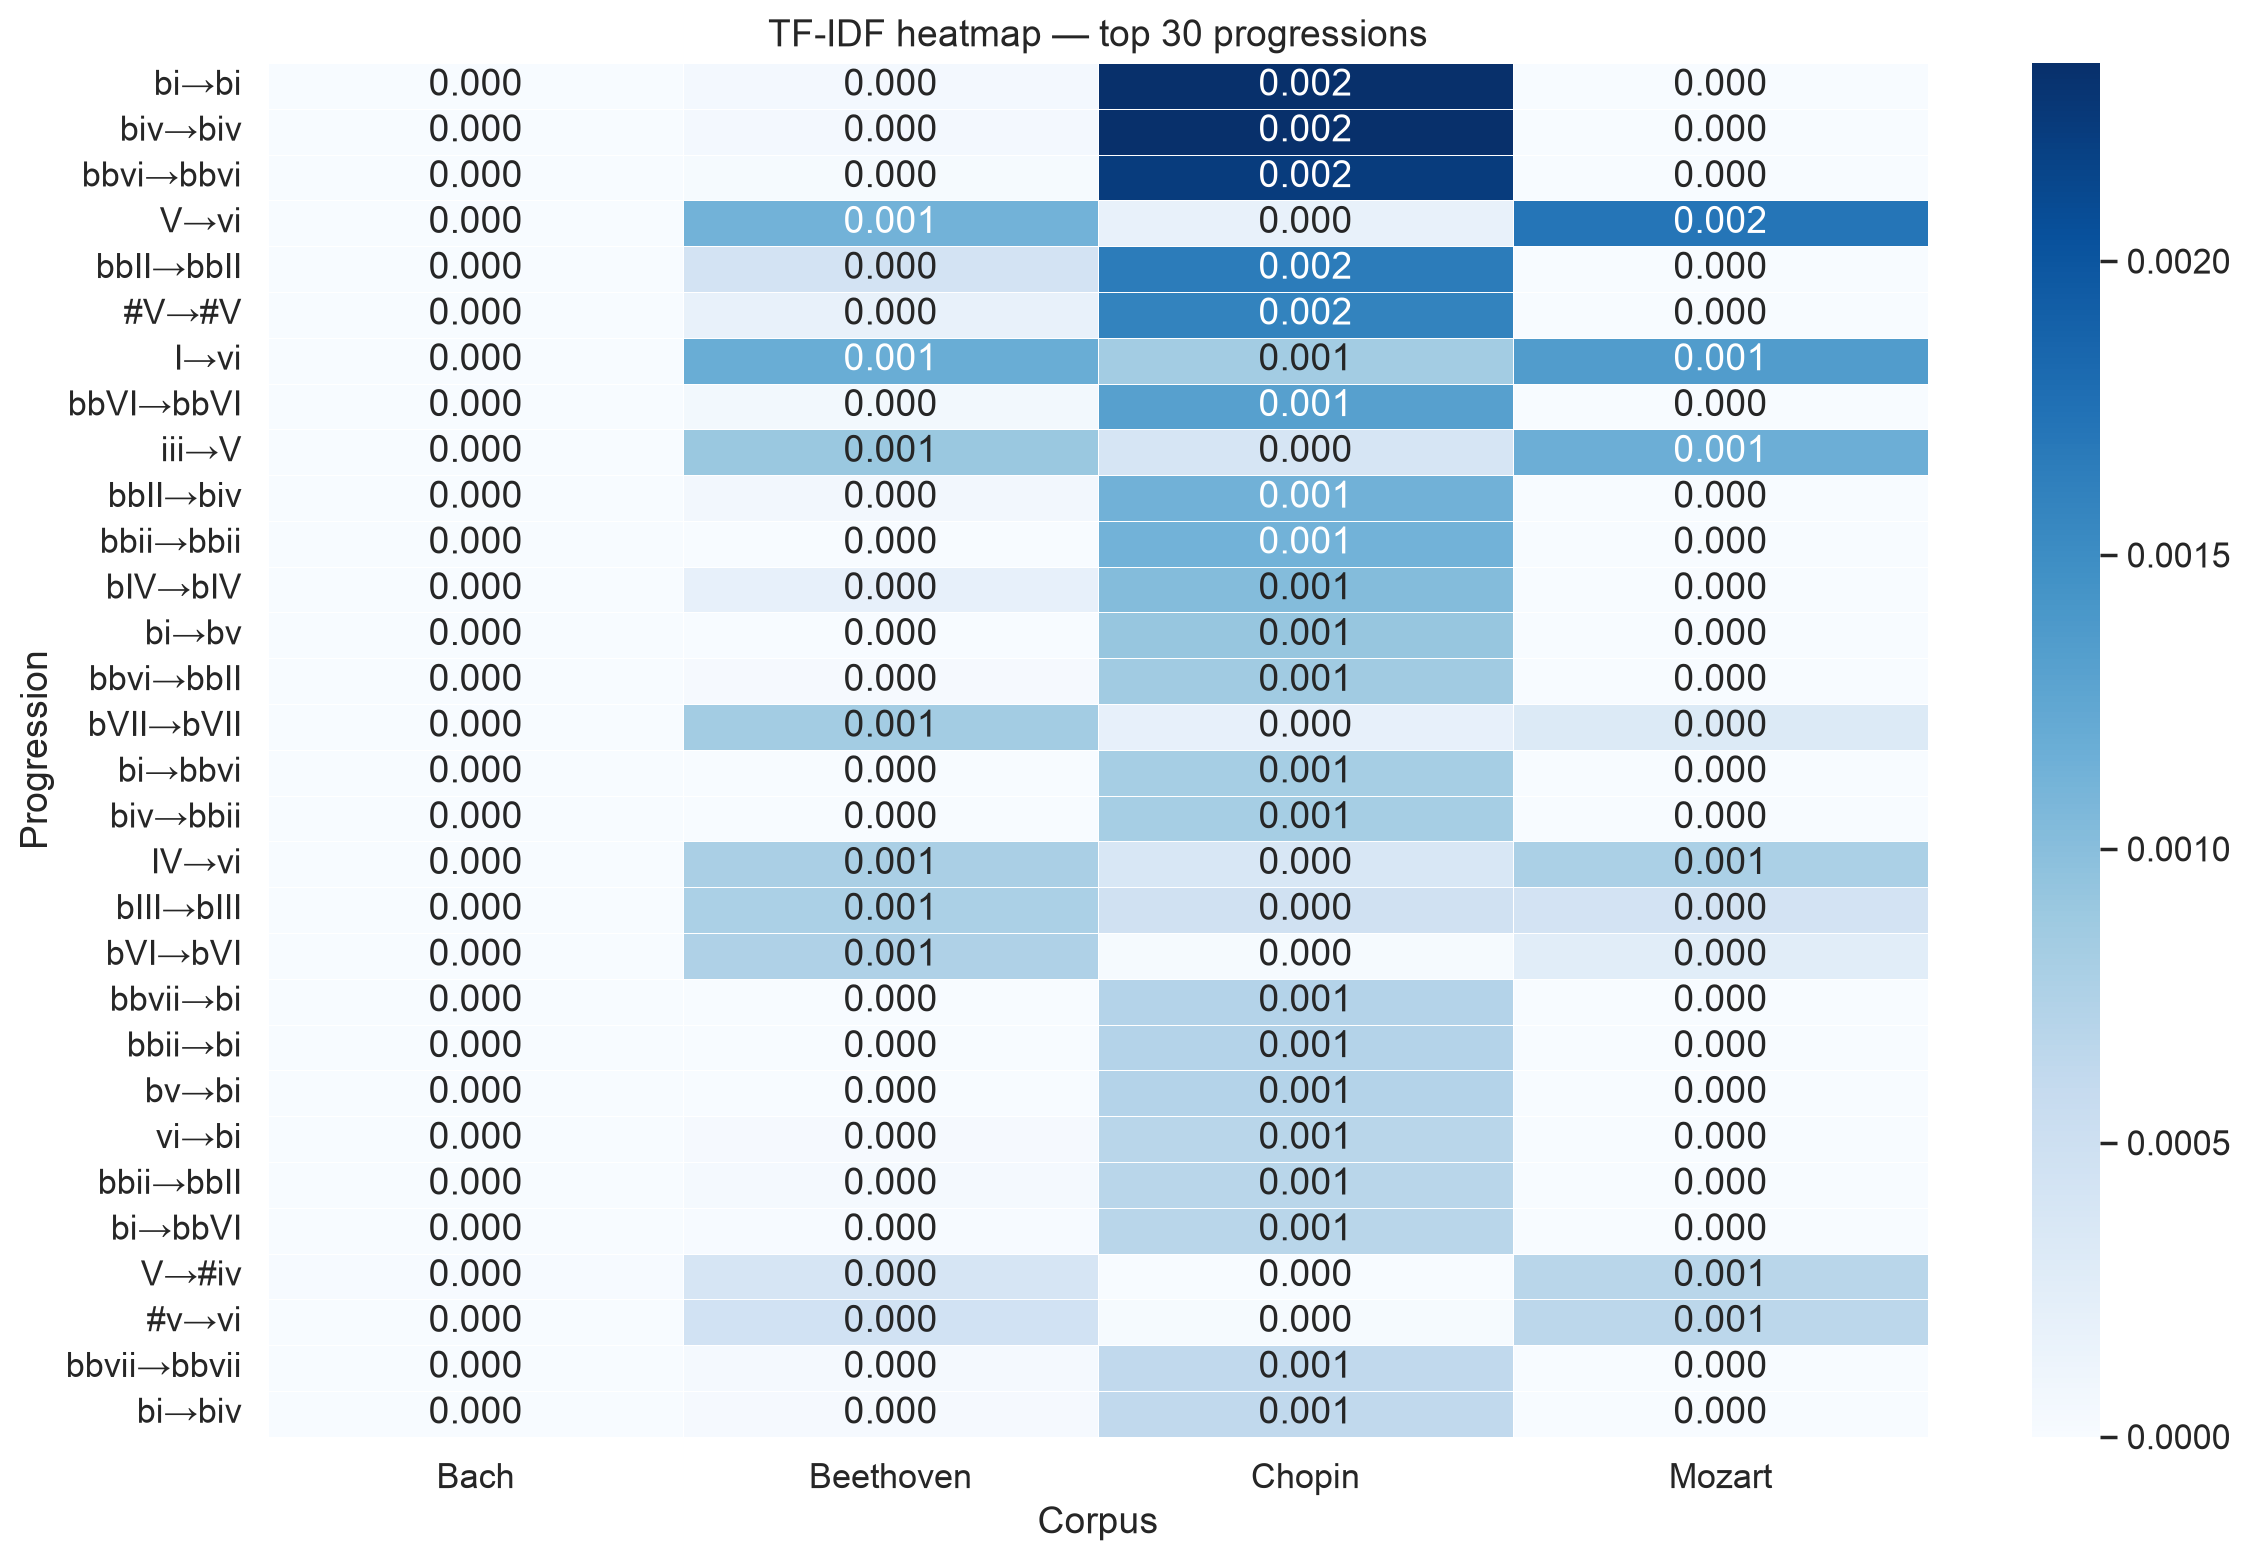

In [ ]:
# Heatmap: all four composers x top distinctive progressions at a glance
from utils import plot_tfidf_heatmap

plot_tfidf_heatmap(harmonic_tfidf, top_n=30);

## Part 5: Bach Chorales -- Harmonic Entropy and Correlation

Everything so far has measured MELODIC entropy. But a chorale is also a
harmonic object -- a sequence of chords. Does a chorale with
unpredictable melodic motion also have unpredictable harmony? Or are
the two independent?

We will build a harmonic entropy measure from scratch (Roman numeral
unigram entropy per chorale), then correlate it against the melodic
entropy we already know how to compute.

NOTE: the Bach chorales in this repo live across three overlapping
folders (`371chorales/`, `chorales.all/`, `chorales.sample/`) that are
mostly the same ~370 chorales under different filenames. We use
`371chorales/` throughout this section -- it is the canonical,
non-duplicated set.


In [ ]:
import music21
from music21 import converter, roman

def harmonic_entropy_single(kern_path, verbose=False):
    '''Return (tune_id, harmonic_entropy, n_chords) for one chorale,
    using Roman-numeral unigram entropy as the harmonic complexity measure.'''
    score = converter.parse(kern_path)
    key = score.analyze('key')
    chordified = score.chordify()

    numerals = []
    for ch in chordified.recurse().getElementsByClass('Chord'):
        try:
            rn = roman.romanNumeralFromChord(ch, key)
            numerals.append(rn.romanNumeral)
        except Exception:
            continue

    if not numerals:
        return None

    counts = pd.Series(numerals).value_counts(normalize=True)
    h = -np.sum(counts * np.log2(counts))

    if verbose:
        print(f'{kern_path}: key={key}, n_chords={len(numerals)}, H={h:.3f}')

    tune_id = Path(kern_path).stem
    return {'tune_id': tune_id, 'harmonic_entropy': h, 'n_chords': len(numerals)}


# Chordify + key analysis is slow, so this loop runs on a 60-chorale subset. 
# You can change it if you'd like. 
chorale_files = sorted(glob.glob('../data/humdrum_scores/Bach/Chorales/371chorales/*.krn'))[:60]
harmonic_rows = []
for f in chorale_files:
    result = harmonic_entropy_single(f, verbose=False)
    if result is not None:
        harmonic_rows.append(result)

harmonic_df = pd.DataFrame(harmonic_rows)
print(f'Computed harmonic entropy for {len(harmonic_df)} chorales.')
harmonic_df.head(10)


Computed harmonic entropy for 60 chorales.


,tune_id,harmonic_entropy,n_chords
0,chor001,2.564230,80
1,chor002,3.297537,79
2,chor003,3.222355,64
3,chor004,3.156555,61
4,chor005,3.345039,123
5,chor006,2.785898,41
6,chor007,3.376848,111
7,chor008,3.350235,124
8,chor009,3.543757,87
9,chor010,3.152478,56


In [ ]:
# Now compute melodic entropy for the same chorales
# (corpus_entropy_profile() takes a directory or single file.
# so we point it at the whole 371chorales folder and let the merge below
# narrow it down to just the chorales we computed harmonic entropy for)
from utils import corpus_entropy_profile

melodic_df = corpus_entropy_profile(
    '../data/humdrum_scores/Bach/Chorales/371chorales',
    representation='scale_degree',
    verbose=False, plot=False)
melodic_df = melodic_df.rename(columns={'entropy': 'melodic_entropy'})

##merge with the ones we have harmonic entropy for...
merged = harmonic_df.merge(melodic_df[['tune_id', 'melodic_entropy', 'n_notes']],
                            on='tune_id', how='inner')

## print results
print(f'Chorales with both harmonic and melodic entropy: {len(merged)}')
merged.head(20)


370 piece(s) — entropy (scale_degree): mean=2.887, median=2.895, min=2.724, max=2.964
Chorales with both harmonic and melodic entropy: 60


,tune_id,harmonic_entropy,n_chords,melodic_entropy,n_notes
0,chor001,2.564230,80,2.751188,229
1,chor002,3.297537,79,2.921377,231
2,chor003,3.222355,64,2.824696,196
3,chor004,3.156555,61,2.872681,186
4,chor005,3.345039,123,2.904893,333
5,chor006,2.785898,41,2.804092,125
6,chor007,3.376848,111,2.916162,346
7,chor008,3.350235,124,2.918357,358
8,chor009,3.543757,87,2.948614,243
9,chor010,3.152478,56,2.925384,182


In [14]:
# Pearson correlation: do harmonic and melodic entropy move together?
from scipy.stats import pearsonr

r, p = pearsonr(merged['harmonic_entropy'], merged['melodic_entropy'])
print(f'Pearson r = {r:.3f}, p = {p:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged['harmonic_entropy'], merged['melodic_entropy'],
           alpha=0.6, color='steelblue')
slope_h, intercept_h = np.polyfit(merged['harmonic_entropy'],
                                   merged['melodic_entropy'], 1)
x_range = np.linspace(merged['harmonic_entropy'].min(),
                       merged['harmonic_entropy'].max(), 100)
ax.plot(x_range, slope_h * x_range + intercept_h, color='coral', linewidth=2)
ax.set_xlabel('Harmonic entropy (Roman numeral unigrams)')
ax.set_ylabel('Melodic entropy (scale degrees)')
ax.set_title(f'Harmonic vs melodic entropy in Bach chorales (r={r:.2f})')
plt.tight_layout()
plt.show()


NameError: name 'merged' is not defined

### What this correlation means

A positive r here means chorales with more harmonically varied
progressions also tend to have more melodically variability.    
Bach's harmonic and melodic choices move together rather than independently.
It makes sense and isn't too interesting!

An r near zero would say the two are essentially unrelated: a chorale
can be harmonically adventurous with a plain tune, or the reverse, with
no consistent pattern either way. 

In [15]:
# Multiple regression: can we predict harmonic entropy from melodic features?
# If yes, melodic complexity is a proxy for harmonic complexity in Bach
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_cols = ['melodic_entropy', 'n_notes']
X = reg_df[X_cols].values
y = reg_df['harmonic_entropy'].values   # ← predicting THIS

X_scaled = StandardScaler().fit_transform(X)
model = LinearRegression().fit(X_scaled, y)

r2 = model.score(X_scaled, y)
print(f'R² = {r2:.3f}  ({r2*100:.1f}% of variance in harmonic entropy explained)\n')

coef_df = pd.DataFrame({
    'Feature':           X_cols,
    'β (standardized)':  model.coef_,
    'Hypothesis':        [
        'More melodic complexity → more harmonic complexity?',
        'Longer piece → more harmonic variety?',
    ]
}).sort_values('β (standardized)', key=abs, ascending=False)

display(coef_df.round(3))
print()
print('Key question: after controlling for piece length (n_notes),')
print('does melodic entropy still predict harmonic entropy?')
print('If yes: Bach couples melodic and harmonic complexity.')
print('If no: the Pearson correlation was driven by length alone.')

NameError: name 'reg_df' is not defined

## Reading the multiple regression

**R² = 0.544** — the two predictors together explain 54% of the 
variance in harmonic entropy across the Bach chorales. That's 
a substantial amount for a model with only two variables.

**melodic_entropy: β = 0.177**
- After controlling for piece length, chorales with higher melodic entropy also tend to have higher 
harmonic entropy. 
- The relationship is positive and meaningful — Bach appears to couple melodic and harmonic complexity. 
- When the soprano line moves through a wider variety of scale degrees, 
the underlying harmony tends to be more varied too.

**n_notes: β = 0.030**
- Piece length is a much weaker predictor. Once you know the 
melodic entropy, knowing the length barely helps. Longer chorales 
are not systematically more harmonically complex than shorter ones.


**What the R² does not tell you:**

- 54% of variance explained means 46% is unexplained by these 
two features. 
- What's in that 46%? Mode (major vs minor) is 
likely a significant missing predictor — minor chorales use 
more chromatic chords and would drive harmonic entropy up 
independently of melodic complexity. 
- The number of voice parts, the presence of text-painting, and the liturgical 
occasion the chorale was written for might all contribute.



We can also look at how each of these correlate with one another...

In [ ]:
print(reg_df[['harmonic_entropy', 'n_chords', 'n_notes']].corr().round(3))

NameError: name 'reg_df' is not defined

In [ ]:
# Check if tune_ids match the actual filenames
print('First few tune_ids in merged:')
print(merged['tune_id'].head(5).tolist())
print()

# Check if those files actually exist
import os
for tid in merged['tune_id'].head(3):
    path = f'../data/humdrum_scores/Bach/Chorales/{tid}.krn'
    print(f'{path}: exists={os.path.exists(path)}')

First few tune_ids in merged:


NameError: name 'merged' is not defined

## Part 6: IDyOM and Enculturation

Everything in Parts 2-5 measured STYLISTIC entropy: how unpredictable
is this corpus, in general, to nobody in particular? IDyOM (Pearce
2005) asks a different question: how unpredictable is this piece to a
SPECIFIC listener, with a specific listening history?

The model combines two predictive sources:

- A **long-term model (LTM)**, trained ahead of time on a corpus of
  other pieces -- representing stable, learned style knowledge.
- A **short-term model (STM)**, trained online from scratch on the
  piece currently being heard -- representing what's been learned
  about THIS piece so far.

The two are combined, weighted by how confident each one currently is.
This is a model of enculturation: the same piece produces a different
surprise contour depending on what corpus trained the LTM.


### STM and LTM

The key observation the figure is built to support: the SAME melody
produces a DIFFERENT surprise contour depending on what corpus trained
the listener. A listener enculturated on one tradition is surprised by
different notes than a listener enculturated on another -- even though
the notes on the page never change. Surprise is not a property of the
music alone; it is a property of the music AND the listening history
brought to it.

Below, we build a small version of this comparison directly: an LTM
trained on Czech folk songs vs. an LTM trained on Bach chorales, both
tested on the same melody (Happy Birthday).


Trained LTM (n=3, by=pitch_class) on 43 piece(s).
Trained LTM (n=3, by=pitch_class) on 370 piece(s).
Mean information content: 3.340 bits
Most surprising note: 'C' at position 19 (4.503 bits)


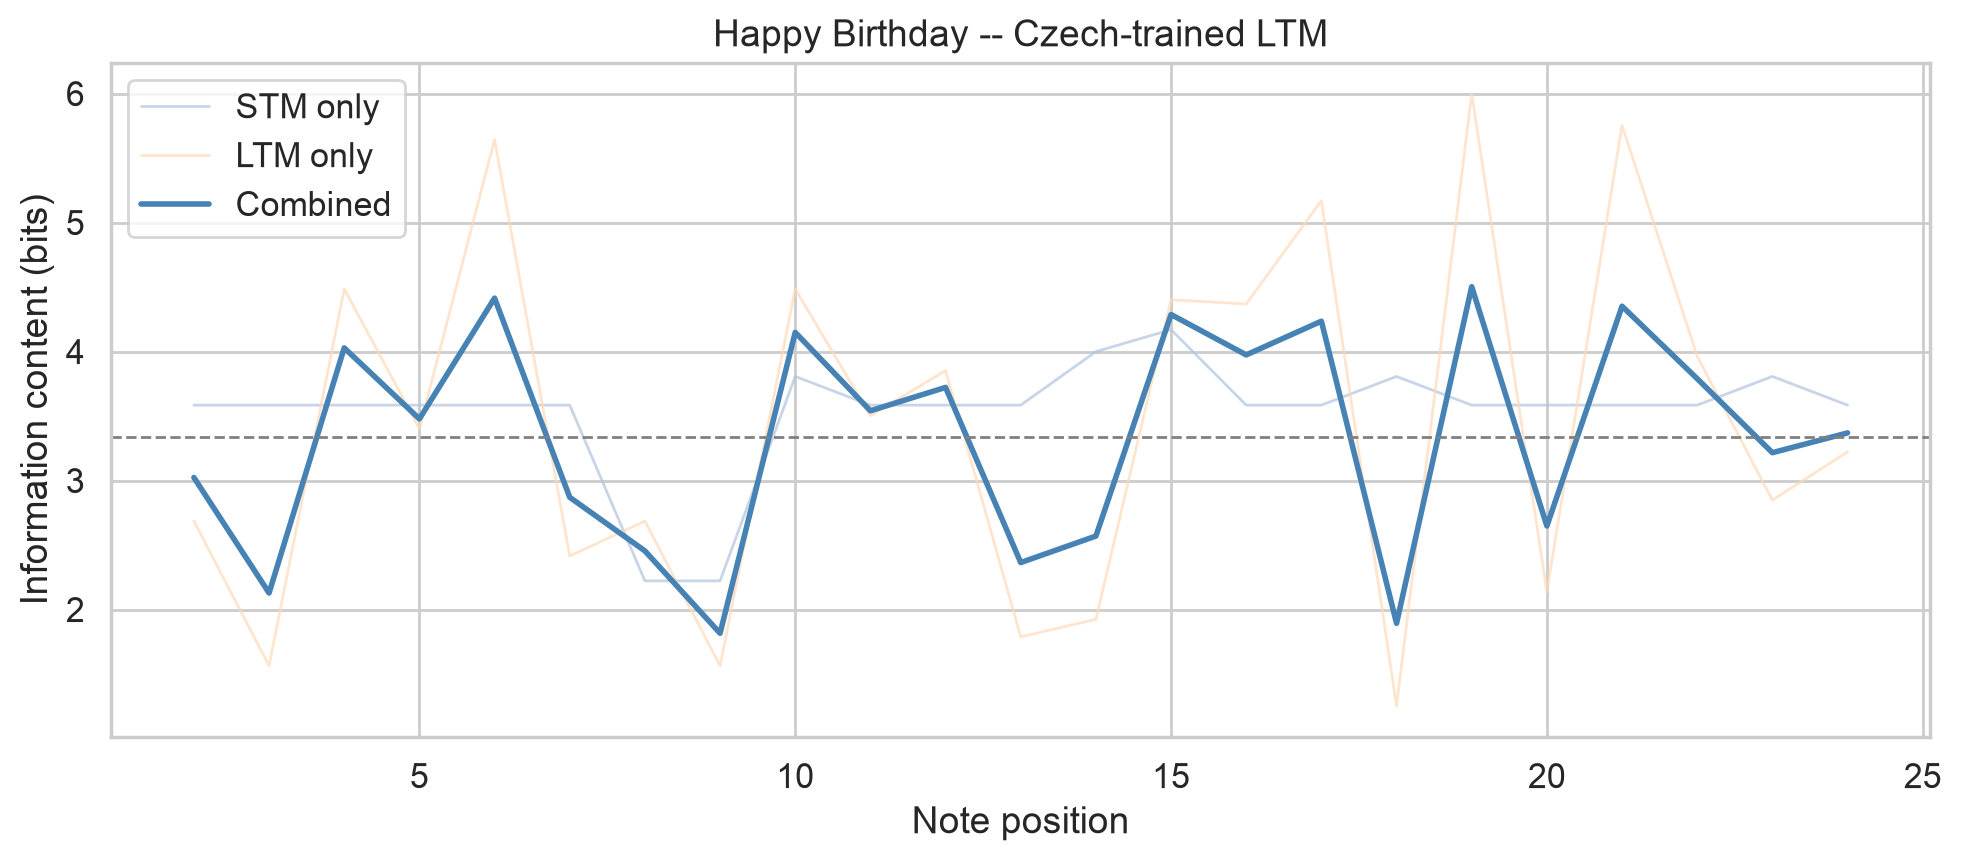

Mean information content: 3.181 bits
Most surprising note: 'C' at position 19 (4.717 bits)


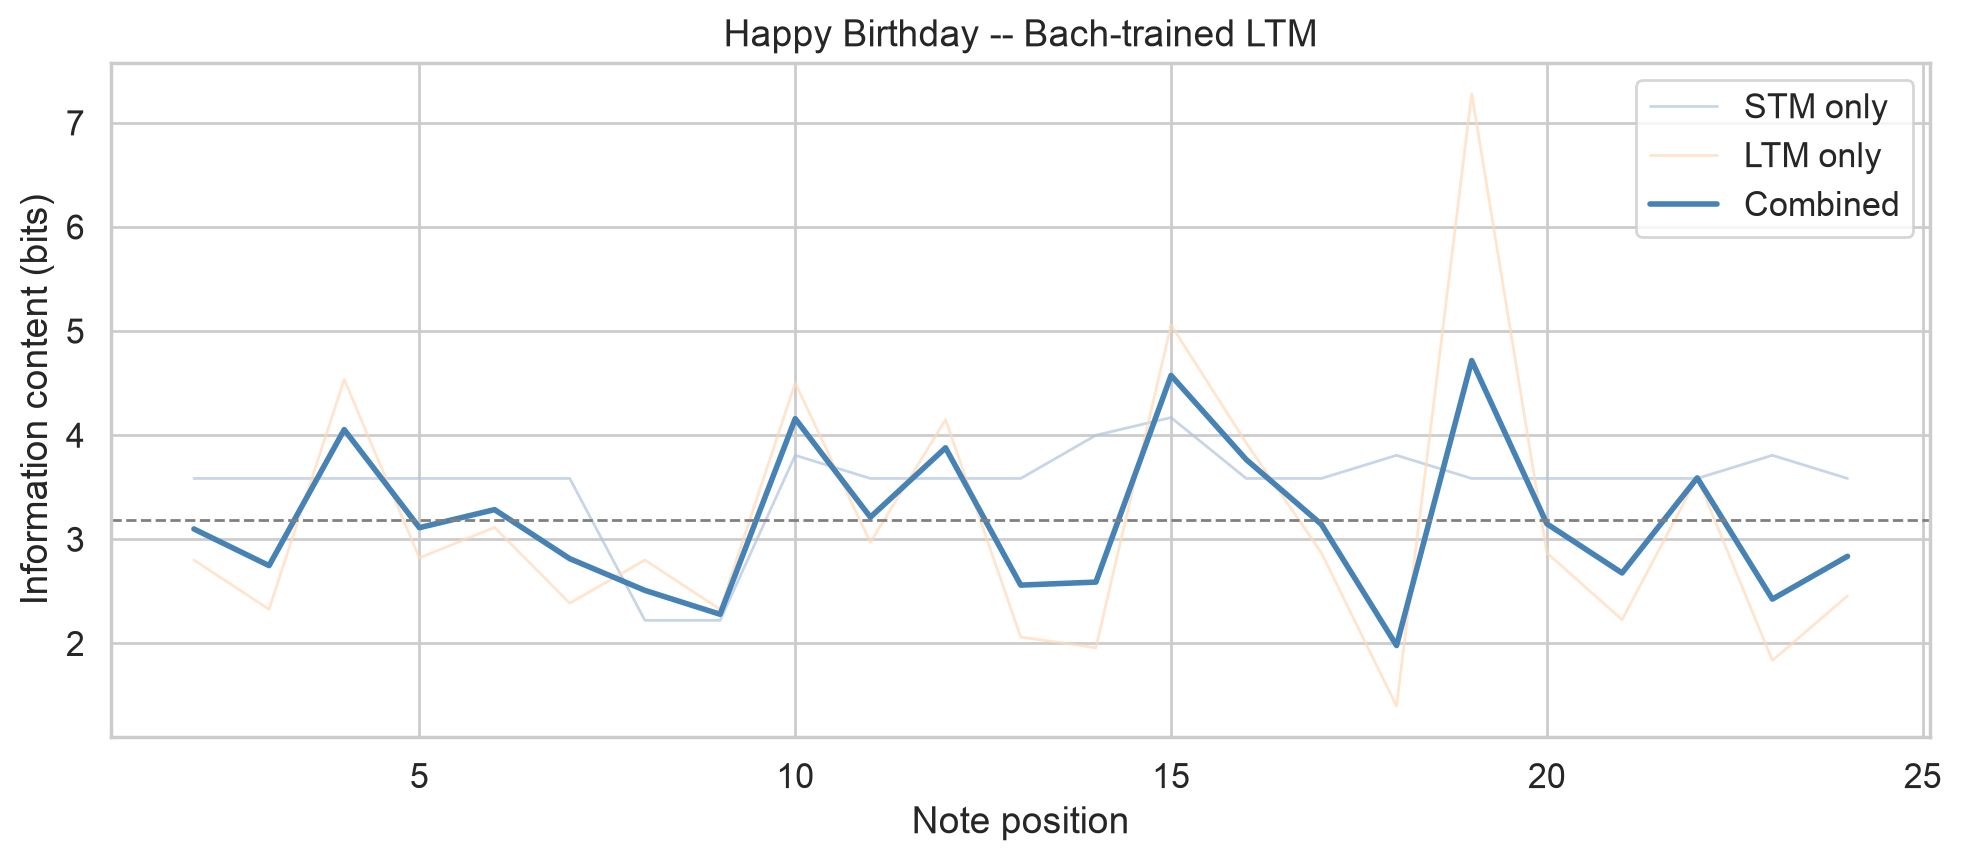

Mean IC (Czech-trained listener): 3.340 bits
Mean IC (Bach-trained listener):  3.181 bits


In [ ]:
# Train two LTMs on different corpora, then compare their surprise
# contours on the SAME test melody (Happy Birthday)
from utils import train_ltm_model, surprise_contour


###let's train two long term models
ltm_czech = train_ltm_model('../data/Essen/Czech', n=3, by='pitch_class')
ltm_bach = train_ltm_model(
    '../data/humdrum_scores/Bach/Chorales/371chorales',
    n=3, by='pitch_class')

result_czech = surprise_contour(
    '../data/happy_birthday.krn', ltm_model=ltm_czech,
    plot=True, title='Happy Birthday -- Czech-trained LTM')

result_bach = surprise_contour(
    '../data/happy_birthday.krn', ltm_model=ltm_bach,
    plot=True, title='Happy Birthday -- Bach-trained LTM')

print(f'Mean IC (Czech-trained listener): {result_czech["ic_combined"].mean():.3f} bits')
print(f'Mean IC (Bach-trained listener):  {result_bach["ic_combined"].mean():.3f} bits')


### Reading this comparison

- **Setup**: two long-term models (LTMs) are trained on different corpora — one on 43 Czech folk songs, one on 370 Bach chorales — and both are tested on the same melody, Happy Birthday. Each LTM is blended with a short-term model (STM) that learns the piece itself as it plays.

- **The three lines**: STM only is surprise judged purely from notes already heard *in this piece*. LTM only (tan) is surprise judged purely from the trained style. Combined (dark blue) blends the two, weighted by each model's confidence — this is the actual IDyOM-style prediction.

- **Mean surprise**: the Czech-trained listener averages 3.340 bits; the Bach-trained listener averages 3.181 bits. Slightly lower for Bach — this listener finds Happy Birthday marginally less surprising overall.

- **Most surprising note**: both listeners flag the same note — the C at position 19 — as the single biggest surprise, though the Bach-trained listener rates it as more surprising (4.717 bits vs. 4.503 bits).

- **The takeaway**: the *same* melody produces a *different* surprise contour depending on what corpus trained the listener. This is the central claim of Part 6 — surprise isn't a property of the notes alone, it's a property of the notes plus the listening history brought to them.

- **One thing worth poking at**: both listeners agreeing on *which* note is most surprising (position 19) raises a question — is that genuinely something unusual about that note regardless of training corpus, or a coincidence in this one example? Worth listening to that moment in the melody to judge for yourself.

In [ ]:
# The IDyOM sweep below recomputes a blended surprise value many times --
# this cell can take a little while to run.
from utils import stm_information_content, ltm_information_content, information_content

# combine_ltm_stm() sets the STM/LTM balance automatically (by each
# model's confidence). To literally sweep "0% STM / 100% LTM" through
# "100% STM / 0% LTM" as the spec asks for, we use a small local helper
# with an EXPLICIT, fixed weight instead of the automatic one.
def mean_ic_at_weight(stm_df, stm_probs, ltm_df, ltm_probs, w):
    '''Mean information content when blending STM and LTM with a fixed
    weight w (w=0 -> pure LTM, w=1 -> pure STM), rather than letting the
    two models' relative confidence set the weight automatically.'''
    merged = stm_df.merge(ltm_df, on=['position', 'symbol'], suffixes=('_stm', '_ltm'))
    stm_pos_to_idx = {p: i for i, p in enumerate(stm_df['position'])}
    ltm_pos_to_idx = {p: i for i, p in enumerate(ltm_df['position'])}
    ics = []
    for _, row in merged.iterrows():
        p_stm = stm_probs[stm_pos_to_idx[row['position']]]
        p_ltm = ltm_probs[ltm_pos_to_idx[row['position']]]
        combined = {s: w * p_stm[s] + (1 - w) * p_ltm[s] for s in p_stm}
        ics.append(information_content(row['symbol'], combined))
    return float(np.mean(ics))

stm_df, stm_probs = stm_information_content('../data/happy_birthday.krn', n=3, by='pitch_class')
ltm_df_czech, ltm_probs_czech = ltm_information_content('../data/happy_birthday.krn', ltm_czech)
ltm_df_bach, ltm_probs_bach = ltm_information_content('../data/happy_birthday.krn', ltm_bach)

stm_weights = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]
czech_curve = [mean_ic_at_weight(stm_df, stm_probs, ltm_df_czech, ltm_probs_czech, w)
               for w in stm_weights]
bach_curve = [mean_ic_at_weight(stm_df, stm_probs, ltm_df_bach, ltm_probs_bach, w)
              for w in stm_weights]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(stm_weights, czech_curve, marker='o', label='Czech-trained LTM', color='steelblue')
ax.plot(stm_weights, bach_curve, marker='o', label='Bach-trained LTM', color='coral')
ax.set_xlabel('STM weight (0 = pure LTM, 1 = pure STM)')
ax.set_ylabel('Mean information content (bits)')
ax.set_title('Happy Birthday: surprise as a function of LTM/STM balance')
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'ltm_czech' is not defined

### Reading the STM/LTM sweep

At weight 0 (pure LTM), the two curves sit apart: a Czech-trained
listener and a Bach-trained listener disagree about how surprising
Happy Birthday is, because each is judging the melody purely against a
different prior style. As the STM weight rises, both curves drop
sharply and converge -- the steep elbow near x=0.1 is the point where
even a small amount of direct exposure to the actual notes of the
piece starts to dominate over whatever style the listener arrived
with. By weight 1 (pure STM), the two listeners agree almost
completely, because neither is using prior style knowledge anymore --
both are just predicting the next note from what they've already
heard of this piece. This is the same shape Figure 6.5 shows for
information content across note position: differently-trained
listeners diverge most when prior knowledge matters most, and
converge as within-piece learning takes over. The difference is that
Figure 6.5 plots divergence across the melody's timeline for fixed
listeners, while this plot holds the melody fixed and varies how much
weight a listener gives to prior knowledge versus what they're hearing
right now.


### What IDyOM leaves out

Siromoney and Rajagopalan (1964) analyzed Carnatic ragas and found
structural principles -- gamaka (ornamentation), microtonal
inflection, raga-specific melodic grammar -- that have no equivalent
in a pitch-class or scale-degree n-gram model. IDyOM-style models were
built around, and validated against, Western tonal listeners. The
LTM/STM architecture is general, but the alphabet (`pitch_class` or
`scale_degree`) and the very idea of a "note" as the unit of
prediction both encode Western assumptions.

A model trained on Carnatic ragas using a 12-pitch-class alphabet would
throw away exactly the information (microtonal inflection) that makes
raga performance what it is. The model isn't wrong, exactly -- it's
answering a question that was never asked in the tradition it's being
applied to.


## Discussion

Across today's notebook we made (or tested) three claims:

1. Entropy increases diachronically in the Western art music corpus
   (Hiller and Bean's claim, tested in Part 3).
2. Harmonic and melodic entropy are correlated within Bach's chorales
   (tested in Part 5).
3. TF-IDF finds melodic/harmonic patterns that are genuinely
   distinctive across traditions, not statistical noise (tested in
   Part 4).


## Email to Dan
(As an email to Dan) answe the following:


1. Which (if any) of today's three parts (entropy over time, TF-IDF, or IDyOM)
   changed how you think about your own corpus project, and how?
2. What is one representation-choice decision you now need to make
   explicitly, that you had been making implicitly?
3. What is one thing in this notebook you do not yet trust, and what
   would it take to convince you?


